# Задание 1 — Инициализация среды

Импортируем все необходимые библиотеки, фиксируем seed для воспроизводимости,
определяем глобальные пути и гиперпараметры, создаём структуру папок проекта.

In [2]:
import os
import random
import sys
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.models as models
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from PIL import Image
from tqdm import tqdm
from glob import glob
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

# ── Пути к данным ──────────────────────────────────────────────────
CSV_PATH       = "cu_data/selected_by_name_iimk_subset_public.csv"
IMAGE_ROOT_DIR = "cu_data/dataset"

# ── Гиперпараметры ─────────────────────────────────────────────────
SEED       = 42
IMAGE_SIZE = 224
EPOCHS     = 30
BATCH_SIZE = 8

# ── Устройство (MPS → CUDA → CPU) ─────────────────────────────────
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# ── Папки проекта ──────────────────────────────────────────────────
folders = [
    "data/raw", "data/interim", "data/processed", "splits",
    "artifacts/checkpoints", "artifacts/preds",
    "artifacts/reports", "artifacts/figures",
]
for folder in folders:
    os.makedirs(folder, exist_ok=True)

print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA:        {torch.cuda.is_available()}")
print(f"Устройство:  {DEVICE}")
print(f"Создано папок: {len(folders)}")


Python:      3.9.6
PyTorch:     2.8.0
Torchvision: 0.23.0
CUDA:        False
Устройство:  mps
Создано папок: 8


# Задание 2 — Загрузка и проверка данных

Проверяем доступность CSV-файла и директории с изображениями,
выводим базовую статистику по датасету.

In [3]:
print("Проверка путей:")
print(f"  CSV:   {CSV_PATH}  |  {'найден' if os.path.exists(CSV_PATH) else 'НЕ НАЙДЕН'}")
print(f"  Фото:  {IMAGE_ROOT_DIR}  |  {'найдена' if os.path.exists(IMAGE_ROOT_DIR) else 'НЕ НАЙДЕНА'}")

if os.path.exists(CSV_PATH) and os.path.exists(IMAGE_ROOT_DIR):
    df = pd.read_csv(CSV_PATH)
    all_files = glob(os.path.join(IMAGE_ROOT_DIR, "**", "*.*"), recursive=True)
    image_files = [f for f in all_files if os.path.splitext(f)[1].lower() in {".jpg", ".jpeg", ".png"}]
    print(f"\nСтрок в CSV:         {len(df)}")
    print(f"Файлов изображений:  {len(image_files)}")
else:
    print("\n[ОШИБКА] Данные не найдены! Проверь пути.")


Проверка путей:
  CSV:   cu_data/selected_by_name_iimk_subset_public.csv  |  найден
  Фото:  cu_data/dataset  |  найдена

Строк в CSV:         1389
Файлов изображений:  1388


# Задание 3 — Структура датасета

Строим маппинг `code → путь к файлу`, проверяем битые пути, дубликаты,
выводим количество строк с валидным путём и несколько примеров изображений.

Всего колонок: 10
Колонки: ['Unnamed: 0', 'code', 'name', 'description', 'material', 'size', 'fragm', 'cultlayer', 'execorg', 'survyear']

Найдено изображений: 1388
Примеры файлов:
  КБ-2014-Р5-0422_orig.jpg
  ВО-1л58-2017-0056_orig.jpg
  КБ-2014-Р2-0332_orig.jpg
  Нц-44-1035_orig.jpg
  ВО-1л58-2017-0503_orig.jpg

Маппинг-записей: 1388
Примеры маппинга:
  КБ-2014-Р5-0422  →  КБ-2014-Р5-0422_orig.jpg
  ВО-1л58-2017-0056  →  ВО-1л58-2017-0056_orig.jpg
  КБ-2014-Р2-0332  →  КБ-2014-Р2-0332_orig.jpg
  Нц-44-1035  →  Нц-44-1035_orig.jpg
  ВО-1л58-2017-0503  →  ВО-1л58-2017-0503_orig.jpg

Ключевое поле ID:       'code'
Строк с валидным путём: 1139
Битых путей:            250
Дублей изображений:     0
Дублей по 'code':       1


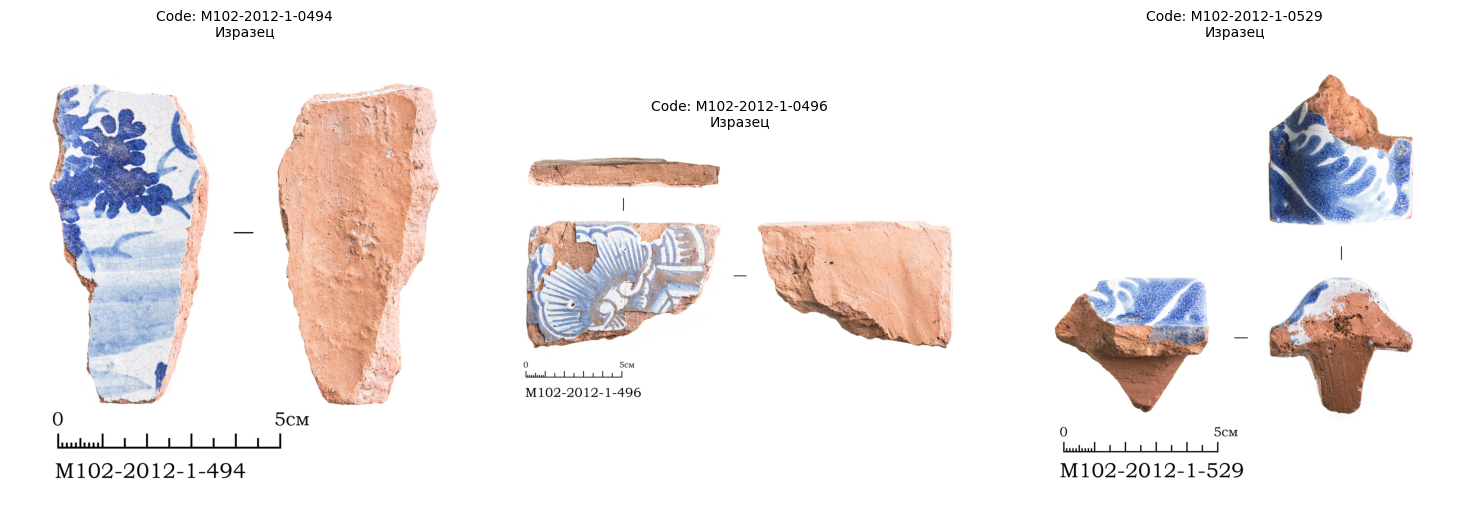

In [4]:
df = pd.read_csv(CSV_PATH)
print(f"Всего колонок: {len(df.columns)}")
print("Колонки:", df.columns.tolist())

all_files = glob(os.path.join(IMAGE_ROOT_DIR, "**", "*.*"), recursive=True)
image_files = [f for f in all_files if f.lower().endswith((".png", ".jpg", ".jpeg"))]
print(f"\nНайдено изображений: {len(image_files)}")

if not image_files:
    print("[ВНИМАНИЕ] Изображения не найдены! Проверьте IMAGE_ROOT_DIR.")
else:
    print("Примеры файлов:")
    for f in image_files[:5]:
        print(f"  {os.path.basename(f)}")

# Маппинг: код артефакта → полный путь
file_dict = {}
for f in image_files:
    basename = os.path.splitext(os.path.basename(f))[0]
    if basename.endswith("_orig"):
        basename = basename[:-5]
    file_dict[basename] = f

print(f"\nМаппинг-записей: {len(file_dict)}")
print("Примеры маппинга:")
for i, (k, v) in enumerate(file_dict.items()):
    if i >= 5:
        break
    print(f"  {k}  →  {os.path.basename(v)}")

df["code_str"]       = df["code"].astype(str).str.strip()
df["full_image_path"] = df["code_str"].map(file_dict)
df["path_exists"]    = df["full_image_path"].notnull()

valid_paths_count  = df["path_exists"].sum()
broken_paths_count = len(df) - valid_paths_count
duplicated_images  = (df["full_image_path"].value_counts() > 1).sum()
duplicated_ids     = df["code"].duplicated().sum()

print(f"\nКлючевое поле ID:       'code'")
print(f"Строк с валидным путём: {valid_paths_count}")
print(f"Битых путей:            {broken_paths_count}")
print(f"Дублей изображений:     {duplicated_images}")
print(f"Дублей по 'code':       {duplicated_ids}")

if valid_paths_count > 0:
    valid_rows = df[df["path_exists"]].head(3)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, (_, row) in zip(axes, valid_rows.iterrows()):
        img = Image.open(row["full_image_path"])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"Code: {row['code']}\n{str(row['name'])[:40]}", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("[ВНИМАНИЕ] Сопоставление не удалось.")
    print("Примеры code из CSV:", df["code"].head(10).tolist())


# Задание 4 — Разведочный анализ (EDA)

Анализируем распределение размеров изображений, соотношения сторон, число ракурсов на артефакт.
Отображаем сетку из 12 случайных изображений, а затем исследуем проблемные примеры:
тёмные снимки, мелкие объекты на большом фоне, нестандартные пропорции кадра.

Собираем размеры изображений...


100%|██████████| 1139/1139 [00:00<00:00, 5278.96it/s]


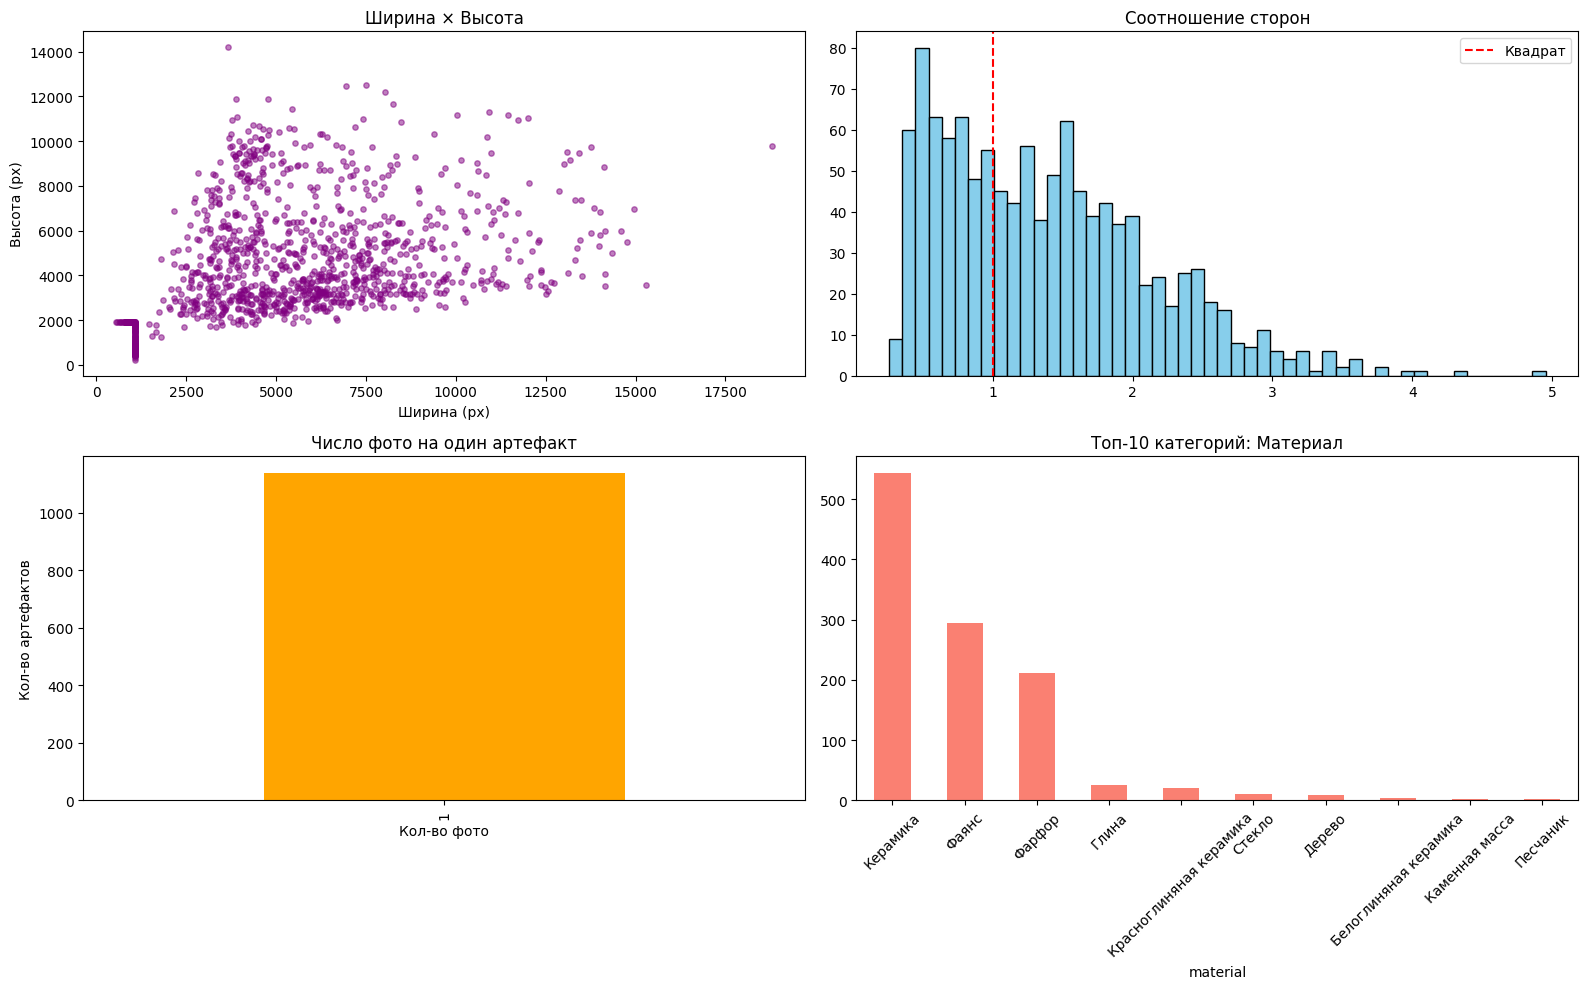

Сетка из 12 случайных изображений:


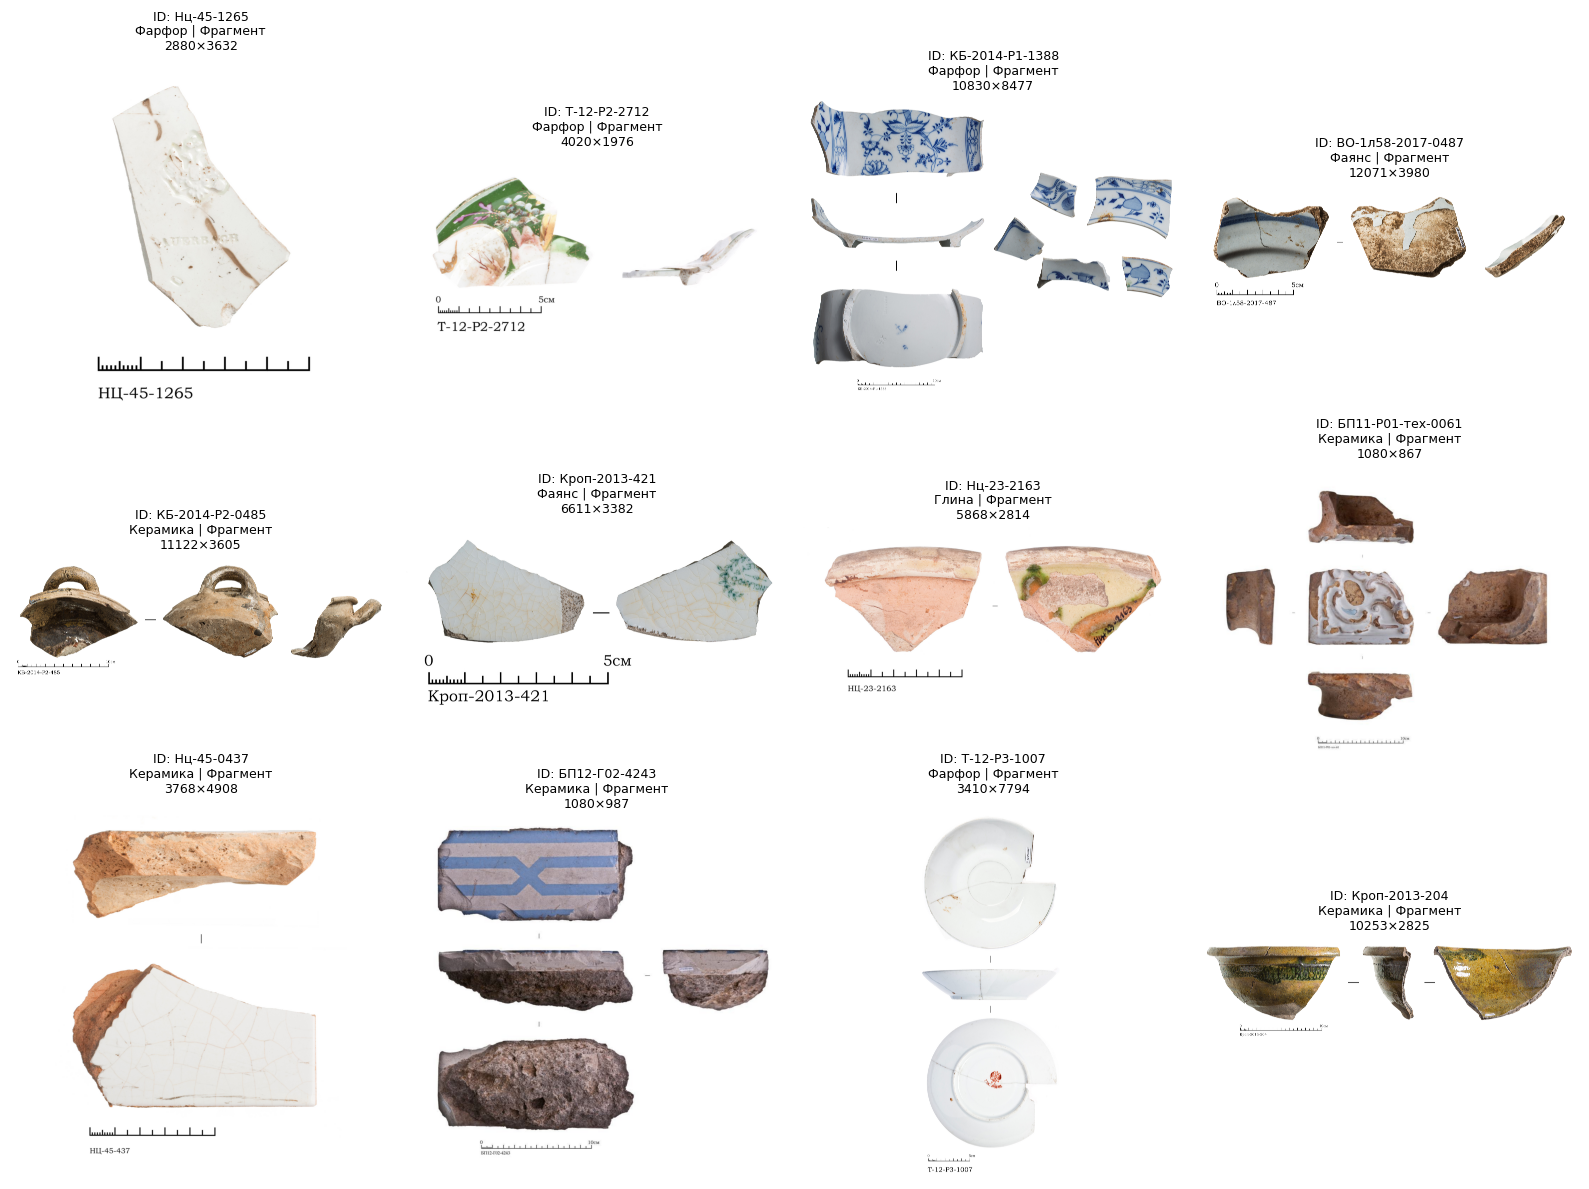

In [5]:
Image.MAX_IMAGE_PIXELS = None
valid_df = df[df["path_exists"]].copy()

print("Собираем размеры изображений...")
widths, heights, aspects = [], [], []
for path in tqdm(valid_df["full_image_path"]):
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)
        aspects.append(w / h)

valid_df["width"]        = widths
valid_df["height"]       = heights
valid_df["aspect_ratio"] = aspects

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].scatter(valid_df["width"], valid_df["height"], alpha=0.5, s=15, color="purple")
axes[0, 0].set_title("Ширина × Высота")
axes[0, 0].set_xlabel("Ширина (px)")
axes[0, 0].set_ylabel("Высота (px)")

axes[0, 1].hist(valid_df["aspect_ratio"], bins=50, color="skyblue", edgecolor="black")
axes[0, 1].set_title("Соотношение сторон")
axes[0, 1].axvline(1.0, color="red", linestyle="--", label="Квадрат")
axes[0, 1].legend()

valid_df["code"].value_counts().value_counts().sort_index().plot(
    kind="bar", ax=axes[1, 0], color="orange"
)
axes[1, 0].set_title("Число фото на один артефакт")
axes[1, 0].set_xlabel("Кол-во фото")
axes[1, 0].set_ylabel("Кол-во артефактов")

valid_df["material"].fillna("Нет данных").value_counts().head(10).plot(
    kind="bar", ax=axes[1, 1], color="salmon"
)
axes[1, 1].set_title("Топ-10 категорий: Материал")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print("Сетка из 12 случайных изображений:")
sample_12 = valid_df.sample(12, random_state=SEED)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (_, row) in zip(axes.flatten(), sample_12.iterrows()):
    img = Image.open(row["full_image_path"])
    ax.imshow(img)
    ax.axis("off")
    mat  = str(row["material"])[:15] if pd.notna(row["material"]) else "—"
    frag = str(row["fragm"])[:15]    if pd.notna(row["fragm"])    else "—"
    ax.set_title(f"ID: {row['code']}\n{mat} | {frag}\n{row['width']}×{row['height']}", fontsize=9)
plt.tight_layout()
plt.show()


Эвристический анализ на подвыборке из 50 изображений...


100%|██████████| 50/50 [00:02<00:00, 20.64it/s]


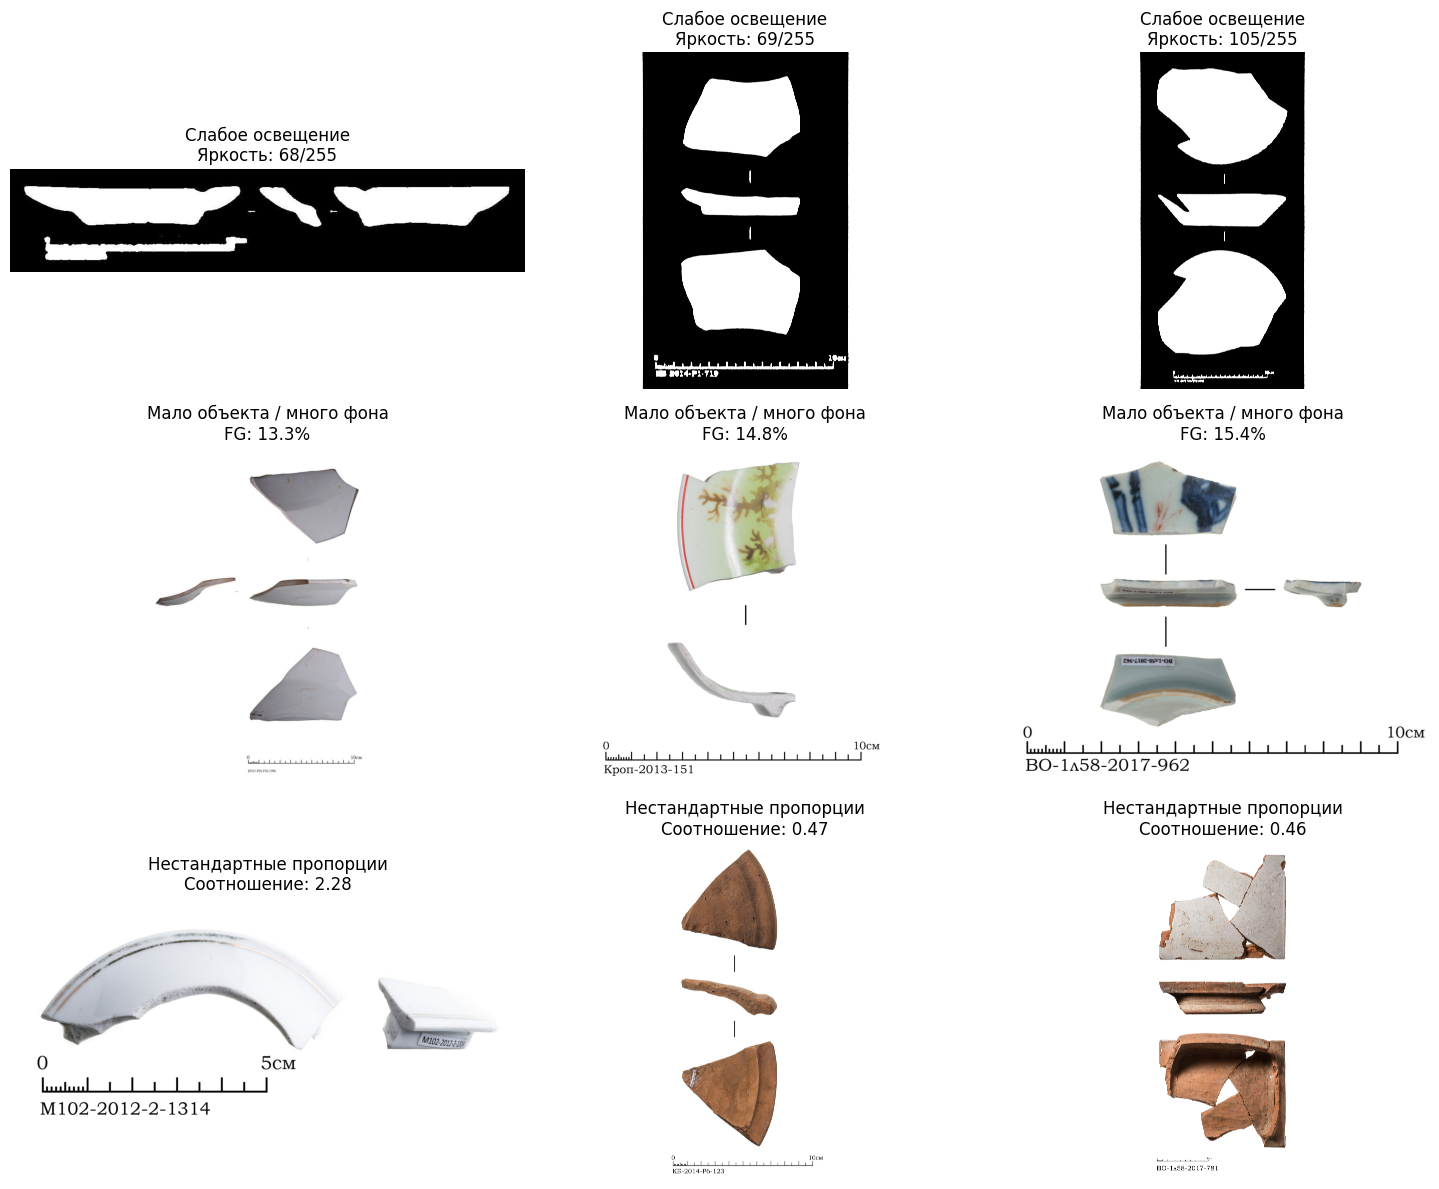

Типы фона (50 фото):
bg_type
Белый            49
Тёмный/прочий     1


In [6]:
print("Эвристический анализ на подвыборке из 50 изображений...")
subset_50 = valid_df.sample(50, random_state=77).copy()

brightness_list, fg_ratio_list, bg_types = [], [], []

for path in tqdm(subset_50["full_image_path"]):
    img_array = np.fromfile(path, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        pil_img = Image.open(path).convert("RGB")
        img = cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness_list.append(np.mean(gray))

    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    fg_ratio_list.append(np.sum(thresh == 255) / thresh.size)

    corners = [gray[0, 0], gray[0, -1], gray[-1, 0], gray[-1, -1]]
    avg_bg = np.mean(corners)
    if avg_bg > 230:
        bg_types.append("Белый")
    elif avg_bg > 180:
        bg_types.append("Светло-серый")
    else:
        bg_types.append("Тёмный/прочий")

subset_50["brightness"] = brightness_list
subset_50["fg_ratio"]   = fg_ratio_list
subset_50["bg_type"]    = bg_types

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for i, (_, row) in enumerate(subset_50.sort_values("brightness").head(3).iterrows()):
    axes[0, i].imshow(Image.open(row["full_image_path"]))
    axes[0, i].set_title(f"Слабое освещение\nЯркость: {row['brightness']:.0f}/255")
    axes[0, i].axis("off")

for i, (_, row) in enumerate(subset_50.sort_values("fg_ratio").head(3).iterrows()):
    axes[1, i].imshow(Image.open(row["full_image_path"]))
    axes[1, i].set_title(f"Мало объекта / много фона\nFG: {row['fg_ratio']:.1%}")
    axes[1, i].axis("off")

weird_aspect = subset_50[(subset_50["aspect_ratio"] > 2.0) | (subset_50["aspect_ratio"] < 0.5)].head(3)
for i, (_, row) in enumerate(weird_aspect.iterrows()):
    axes[2, i].imshow(Image.open(row["full_image_path"]))
    axes[2, i].set_title(f"Нестандартные пропорции\nСоотношение: {row['aspect_ratio']:.2f}")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

print("Типы фона (50 фото):")
print(subset_50["bg_type"].value_counts().to_string())


# Задание 5 — Анализ полей и визуальных режимов

Выбираем поля, которые модель может предсказывать по изображению, и исключаем
поля с метаданными раскопа (культурный слой, год). Для каждого поля оцениваем:
тип задачи, число классов, долю пропусков и риск неоднозначности.

**Итог:** в baseline берём `fragm` (целостность) и `material` (материал).
`description`, `cultlayer`, `survyear` — в baseline не включаем.

In [7]:
valid_df = df[df["path_exists"]].copy()

print("15 примеров реальных описаний:")
sample_texts = valid_df.dropna(subset=["description"]).sample(15, random_state=SEED)
for _, row in sample_texts.iterrows():
    mat  = str(row["material"]) if pd.notna(row["material"]) else "—"
    frag = str(row["fragm"])    if pd.notna(row["fragm"])    else "—"
    desc = str(row["description"]).replace("\n", " ")
    print(f"ID: {row['code']}")
    print(f"  Тип: {row['name']}  |  Мат: {mat}  |  Целостность: {frag}")
    print(f"  Описание: {desc}")
    print("-" * 60)

candidates_data = [
    {
        "Поле": "fragm (Целостность)",
        "Визуально": "Форма и обрывы краёв однозначны",
        "Тип цели": "single-label",
        "Классов": f"~{valid_df['fragm'].nunique()} → 3-4 после нормализации",
        "Пропуски": f"{valid_df['fragm'].isna().mean():.1%}",
        "Риск": "Низкий",
    },
    {
        "Поле": "material (Материал)",
        "Визуально": "Текстура, блеск, цвет, сколы",
        "Тип цели": "single-label",
        "Классов": f"~{valid_df['material'].nunique()} → нужна нормализация",
        "Пропуски": f"{valid_df['material'].isna().mean():.1%}",
        "Риск": "Средний (фаянс vs фарфор)",
    },
    {
        "Поле": "name (Тип предмета)",
        "Визуально": "Геометрия предмета",
        "Тип цели": "single-label",
        "Классов": f"~{valid_df['name'].nunique()} → жёсткий парсинг синонимов",
        "Пропуски": f"{valid_df['name'].isna().mean():.1%}",
        "Риск": "Высокий (много синонимов)",
    },
    {
        "Поле": "description",
        "Визуально": "НЕТ — исторический контекст",
        "Тип цели": "не брать в baseline",
        "Классов": "—",
        "Пропуски": f"{valid_df['description'].isna().mean():.1%}",
        "Риск": "Критический",
    },
    {
        "Поле": "cultlayer / survyear",
        "Визуально": "НЕТ — метаданные раскопа",
        "Тип цели": "не брать в baseline",
        "Классов": "—",
        "Пропуски": "—",
        "Риск": "100% зависимость от контекста",
    },
]
display(pd.DataFrame(candidates_data))

print("\nТоп-15 сырых значений поля material:")
print(valid_df["material"].value_counts(dropna=False).head(15).to_string())
print("\nТоп-15 сырых значений поля fragm:")
print(valid_df["fragm"].value_counts(dropna=False).head(15).to_string())


15 примеров реальных описаний:
ID: Нц-45-1265
  Тип: Тарелка  |  Мат: Фарфор  |  Целостность: Фрагмент
  Описание: Тарелки фарфоровой с клеймом донца фр-т
------------------------------------------------------------
ID: Т-12-Р2-2712
  Тип: Блюдце  |  Мат: Фарфор  |  Целостность: Фрагмент
  Описание: Блюдца фарфорового профиля фр-т
------------------------------------------------------------
ID: КБ-2014-Р1-1388
  Тип: Тарелка  |  Мат: Фарфор  |  Целостность: Фрагмент
  Описание: Тарелки фарфоровой с синим цветочным рисунком внутри придонной части фрагмент клеймо снаружи вдавлено "Мeissen…2 1/2"  подглазурно синим "Meissen…39"
------------------------------------------------------------
ID: ВО-1л58-2017-0487
  Тип: Тарелка  |  Мат: Фаянс  |  Целостность: Фрагмент
  Описание: Тарелки фаянсовой с голубой поливой снаружи и внутри с темно-голубой полосой по краю венчика фр-т
------------------------------------------------------------
ID: КБ-2014-Р2-0485
  Тип: Миска  |  Мат: Керамика  |  Це

,Поле,Визуально,Тип цели,Классов,Пропуски,Риск
0,fragm (Целостность),Форма и обрывы краёв однозначны,single-label,~2 → 3-4 после нормализации,0.0%,Низкий
1,material (Материал),"Текстура, блеск, цвет, сколы",single-label,~19 → нужна нормализация,0.0%,Средний (фаянс vs фарфор)
2,name (Тип предмета),Геометрия предмета,single-label,~9 → жёсткий парсинг синонимов,0.0%,Высокий (много синонимов)
3,description,НЕТ — исторический контекст,не брать в baseline,—,0.0%,Критический
4,cultlayer / survyear,НЕТ — метаданные раскопа,не брать в baseline,—,—,100% зависимость от контекста



Топ-15 сырых значений поля material:
material
Керамика                                              544
Фаянс                                                 294
Фарфор                                                212
Глина                                                  25
Красноглиняная керамика                                21
Стекло                                                 11
Дерево                                                  9
Белоглиняная керамика                                   4
Каменная масса                                          3
Песчаник                                                3
Пластмасса                                              2
Основание - бетон, покрытие - композитный материал      2
Светлоглиняная керамика                                 2
Сланец                                                  2
Серолощеная керамика                                    1

Топ-15 сырых значений поля fragm:
fragm
Фрагмент    1047
Целый         92


# Задание 6 — Нормализация меток

Создаём словари нормализации для `material` и `fragm`, приводим сырые значения
к единому виду. Для каждого поля формируем колонки:
`raw_*`, `norm_*`, `*_is_missing`, `*_is_uncertain`.

Пример нормализации (материал):


,raw_material,norm_material,material_is_missing,material_is_uncertain
0,Керамика,керамика,False,False
1,Керамика,керамика,False,False
2,Керамика,керамика,False,False
3,Фаянс,фаянс,False,False
4,Керамика,керамика,False,False


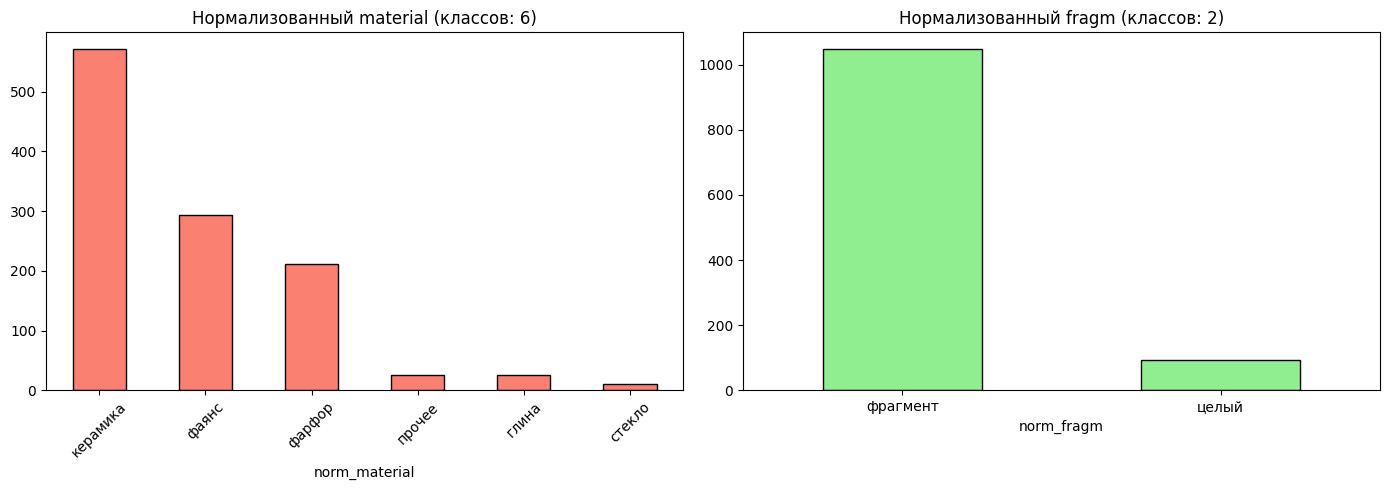

In [8]:
material_dict = {
    "керамика":              "керамика",
    "фаянс":                 "фаянс",
    "фарфор":                "фарфор",
    "стекло":                "стекло",
    "глина":                 "глина",
    "красноглиняная керамика": "керамика",
    "белоглиняная керамика":   "керамика",
    "светлоглиняная керамика": "керамика",
}

fragm_dict = {
    "фрагмент":    "фрагмент",
    "целый":       "целый",
    "фр.":         "фрагмент",
    "фр":          "фрагмент",
    "целая форма": "целый",
}


def normalize_feature(df, col_name, mapping_dict, rare_label="прочее"):
    raw_col      = f"raw_{col_name}"
    norm_col     = f"norm_{col_name}"
    missing_col  = f"{col_name}_is_missing"
    uncertain_col = f"{col_name}_is_uncertain"

    df[raw_col]  = df[col_name].copy()
    cleaned_raw  = df[col_name].astype(str).str.lower().str.strip()

    df[missing_col] = (
        df[col_name].isna()
        | (cleaned_raw == "nan")
        | (cleaned_raw == "")
        | (cleaned_raw == "none")
    )

    df[norm_col] = cleaned_raw.map(mapping_dict)
    mask_unmapped = df[norm_col].isna() & ~df[missing_col]
    df.loc[mask_unmapped, norm_col] = rare_label
    df.loc[df[missing_col], norm_col] = "неизвестно"
    df[uncertain_col] = (
        df[missing_col]
        | (df[norm_col] == rare_label)
        | (df[norm_col] == "неизвестно")
    )
    return df


valid_df = normalize_feature(valid_df, "material", material_dict, rare_label="прочее")
valid_df = normalize_feature(valid_df, "fragm",    fragm_dict,    rare_label="неизвестно")

print("Пример нормализации (материал):")
display(valid_df[["raw_material", "norm_material", "material_is_missing", "material_is_uncertain"]].head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

valid_df["norm_material"].value_counts().plot(
    kind="bar", color="salmon", edgecolor="black", ax=axes[0]
)
axes[0].set_title(f"Нормализованный material (классов: {valid_df['norm_material'].nunique()})")
axes[0].tick_params(axis="x", rotation=45)

valid_df["norm_fragm"].value_counts().plot(
    kind="bar", color="lightgreen", edgecolor="black", ax=axes[1]
)
axes[1].set_title(f"Нормализованный fragm (классов: {valid_df['norm_fragm'].nunique()})")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


# Задание 7 — Шаблон auto_description

Определяем порядок полей в итоговом описании: **целостность → тип → материал**.

Правила сборки:
- Если уверенность поля ≥ 0.7 → значение включается напрямую
- Если 0.4 ≤ уверенность < 0.7 → добавляем `(предположительно)`
- Если уверенность < 0.4 или значение `неизвестно` → поле пропускается

Формула: `auto_description = g(ŷ, c, Θ)`, где `ŷ` — предсказания,
`c` — уверенности, `Θ` — пороги включения/пропуска.

In [9]:
THRESHOLDS = {"certain": 0.7, "uncertain": 0.4}


def generate_auto_description(preds: dict, confs: dict, thresholds: dict) -> str:
    fragm_val  = preds.get("fragm", "неизвестно")
    fragm_conf = confs.get("fragm", 0.0)
    if fragm_conf < thresholds["uncertain"] or fragm_val == "неизвестно":
        text_fragm = "Предмет неизвестной сохранности"
    else:
        text_fragm = fragm_val.capitalize()

    name_val  = preds.get("name", "предмет")
    name_conf = confs.get("name", 0.0)
    if name_conf < thresholds["uncertain"] or name_val == "неизвестно":
        text_name = "неустановленного типа"
    elif name_conf < thresholds["certain"]:
        text_name = f"типа '{name_val}' (предположительно)"
    else:
        text_name = f"типа '{name_val}'"

    mat_val  = preds.get("material", "неизвестно")
    mat_conf = confs.get("material", 0.0)
    if mat_conf < thresholds["uncertain"] or mat_val in ("неизвестно", "прочее"):
        text_mat = ""
    elif mat_conf < thresholds["certain"]:
        text_mat = f", возможный материал: {mat_val}."
    else:
        text_mat = f", материал: {mat_val}."

    return f"{text_fragm} {text_name}{text_mat}"


examples = [
    ({"fragm": "фрагмент",  "name": "изразец",  "material": "керамика"},
     {"fragm": 0.98,        "name": 0.95,        "material": 0.99}),
    ({"fragm": "целый",     "name": "горшок",    "material": "глина"},
     {"fragm": 0.90,        "name": 0.85,        "material": 0.88}),
    ({"fragm": "фрагмент",  "name": "тарелка",   "material": "фарфор"},
     {"fragm": 0.95,        "name": 0.80,        "material": 0.55}),
    ({"fragm": "фрагмент",  "name": "труба",     "material": "стекло"},
     {"fragm": 0.95,        "name": 0.80,        "material": 0.20}),
    ({"fragm": "фрагмент",  "name": "кувшин",    "material": "керамика"},
     {"fragm": 0.95,        "name": 0.50,        "material": 0.90}),
    ({"fragm": "неизвестно","name": "неизвестно", "material": "неизвестно"},
     {"fragm": 0.10,        "name": 0.30,        "material": 0.15}),
]

print("Примеры генерации auto_description:")
for i, (preds, confs) in enumerate(examples, 1):
    desc = generate_auto_description(preds, confs, THRESHOLDS)
    print(f"\nПример {i}:")
    print(f"  Предсказания: {preds}")
    print(f"  Уверенность:  {confs}")
    print(f"  Результат:    {desc}")


Примеры генерации auto_description:

Пример 1:
  Предсказания: {'fragm': 'фрагмент', 'name': 'изразец', 'material': 'керамика'}
  Уверенность:  {'fragm': 0.98, 'name': 0.95, 'material': 0.99}
  Результат:    Фрагмент типа 'изразец', материал: керамика.

Пример 2:
  Предсказания: {'fragm': 'целый', 'name': 'горшок', 'material': 'глина'}
  Уверенность:  {'fragm': 0.9, 'name': 0.85, 'material': 0.88}
  Результат:    Целый типа 'горшок', материал: глина.

Пример 3:
  Предсказания: {'fragm': 'фрагмент', 'name': 'тарелка', 'material': 'фарфор'}
  Уверенность:  {'fragm': 0.95, 'name': 0.8, 'material': 0.55}
  Результат:    Фрагмент типа 'тарелка', возможный материал: фарфор.

Пример 4:
  Предсказания: {'fragm': 'фрагмент', 'name': 'труба', 'material': 'стекло'}
  Уверенность:  {'fragm': 0.95, 'name': 0.8, 'material': 0.2}
  Результат:    Фрагмент типа 'труба'

Пример 5:
  Предсказания: {'fragm': 'фрагмент', 'name': 'кувшин', 'material': 'керамика'}
  Уверенность:  {'fragm': 0.95, 'name': 0.5,

# Задание 8 — Разбивка датасета (Group-Aware Split)

Разбиваем датасет с учётом `group_key = 'code'`: один и тот же артефакт не может
попасть одновременно в train и val/test. Соотношение: **~60 / 20 / 20**.

Проверяем: нулевое пересечение групп между сплитами, воспроизводимость при
том же seed, равномерность распределения классов.

train_inner:  683 (60.0%)
val_inner:    228 (20.0%)
test_open:    228 (20.0%)

Пересечение train ∩ val:  0
Пересечение train ∩ test: 0
Пересечение val ∩ test:   0
Утечек нет — разные ракурсы одного предмета строго разделены по сплитам.

Воспроизводимость (seed=42): 100% идентично


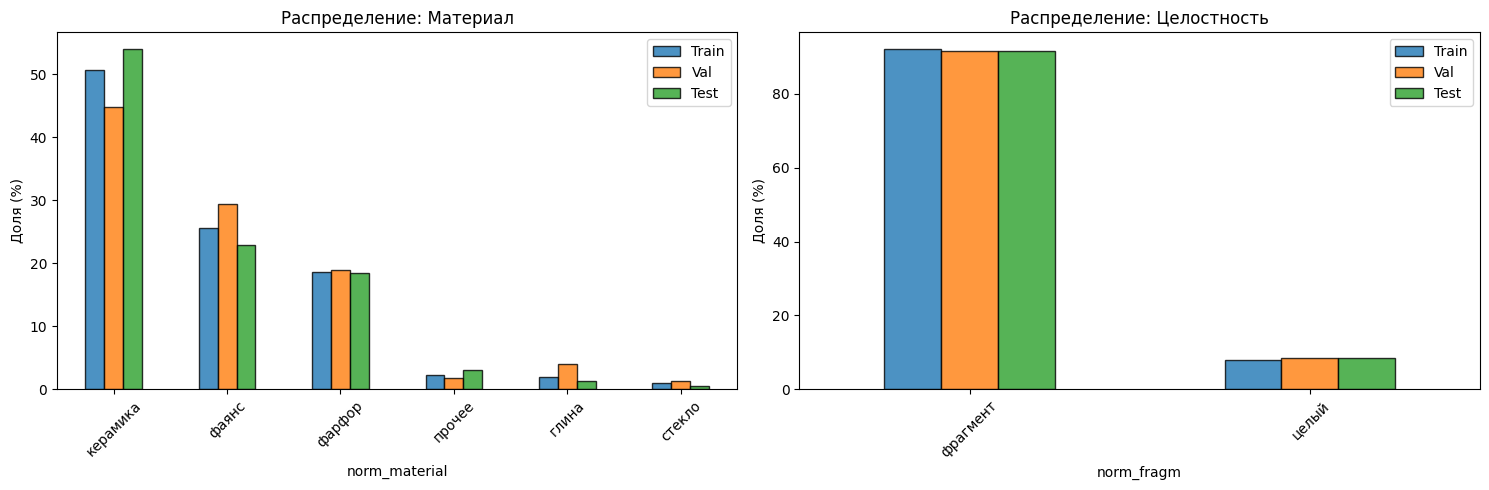

In [10]:
GROUP_COL = "code"


def get_splits(df, group_col, random_state):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=random_state)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df[group_col]))

    train_val_df = df.iloc[train_val_idx].copy()
    test_df      = df.iloc[test_idx].copy()

    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=random_state)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df[group_col]))

    train_df = train_val_df.iloc[train_idx].copy()
    val_df   = train_val_df.iloc[val_idx].copy()

    return train_df, val_df, test_df


train_df, val_df, test_df = get_splits(valid_df, GROUP_COL, SEED)
n = len(valid_df)

print(f"train_inner: {len(train_df):4d} ({len(train_df)/n:.1%})")
print(f"val_inner:   {len(val_df):4d} ({len(val_df)/n:.1%})")
print(f"test_open:   {len(test_df):4d} ({len(test_df)/n:.1%})")

train_g = set(train_df[GROUP_COL])
val_g   = set(val_df[GROUP_COL])
test_g  = set(test_df[GROUP_COL])

print(f"\nПересечение train ∩ val:  {len(train_g & val_g)}")
print(f"Пересечение train ∩ test: {len(train_g & test_g)}")
print(f"Пересечение val ∩ test:   {len(val_g & test_g)}")

if not (train_g & val_g) and not (train_g & test_g):
    print("Утечек нет — разные ракурсы одного предмета строго разделены по сплитам.")

train_df_2, _, _ = get_splits(valid_df, GROUP_COL, SEED)
print(f"\nВоспроизводимость (seed={SEED}): "
      f"{'100% идентично' if train_df.index.equals(train_df_2.index) else 'ОШИБКА!'}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))


def plot_dist(col, ax, title):
    t  = train_df[col].value_counts(normalize=True).rename("Train")
    v  = val_df[col].value_counts(normalize=True).rename("Val")
    te = test_df[col].value_counts(normalize=True).rename("Test")
    pd.concat([t, v, te], axis=1).fillna(0).mul(100).plot(
        kind="bar", ax=ax, edgecolor="black", alpha=0.8
    )
    ax.set_title(title)
    ax.set_ylabel("Доля (%)")
    ax.tick_params(axis="x", rotation=45)


plot_dist("norm_material", axes[0], "Распределение: Материал")
plot_dist("norm_fragm",    axes[1], "Распределение: Целостность")
plt.tight_layout()
plt.show()


# Задание 9 + 10 — Предобработка и Dataset/DataLoader

**Предобработка:** `LongestMaxSize + PadIfNeeded` (белый фон) до `IMAGE_SIZE×IMAGE_SIZE`.

**Train-аугментации:** горизонтальный флип, поворот ±20°, умеренный `BrightnessContrast`,
небольшой сдвиг `HueSaturationValue`. Агрессивные трансформации формы и цвета намеренно
исключены, чтобы не уничтожать сигнал (кроп надписей, масштабная линейка).

**Dataset** возвращает: `image (C,H,W)`, `targets [mat_idx, fragm_idx]`,
`target_mask` (0 если поле `неизвестно`), `metadata`.

/var/folders/f9/07xx41b54m3d8sppgndj5vh80000gn/T/ipykernel_26655/815192312.py:3: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/var/folders/f9/07xx41b54m3d8sppgndj5vh80000gn/T/ipykernel_26655/815192312.py:12: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255]),


Размеры батча:
  images:  torch.Size([8, 3, 224, 224])   dtype=torch.float32
  targets: torch.Size([8, 2])  dtype=torch.int64
  masks:   torch.Size([8, 2])    dtype=torch.float32


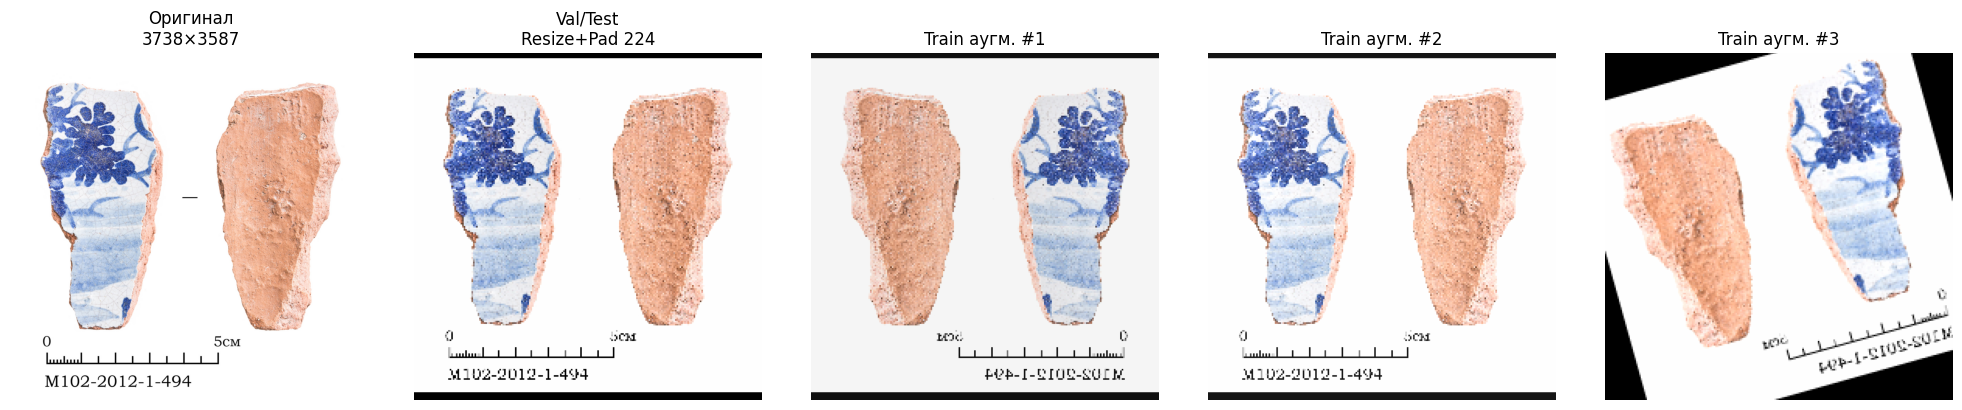


Sanity-check (idx=0):
  Файл:   М102-2012-1-0496_orig.jpg
  Код:    М102-2012-1-0496
  Метки:  материал=керамика, целостность=фрагмент
  Маска:  [1.0, 1.0] (1=данные есть, 0=пропуск)
  auto_description: Фрагмент типа 'предмет', материал: керамика.


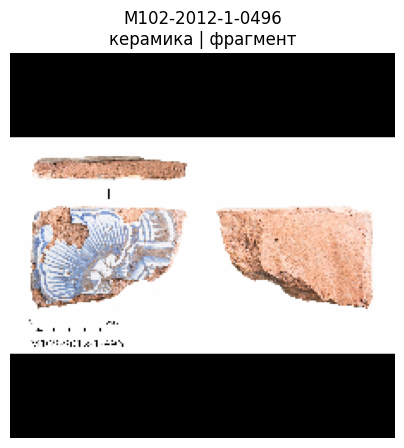


Вал-трансформация детерминирована: True  (diff=0.0)


In [11]:
resize_pad = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(
        min_height=IMAGE_SIZE, min_width=IMAGE_SIZE,
        border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255],
    ),
])

train_transform = A.Compose([
    resize_pad,
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255]),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    resize_pad,
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])


class ArchaeologyDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

        self.mat_classes   = sorted(self.df["norm_material"].unique().tolist())
        self.fragm_classes = sorted(self.df["norm_fragm"].unique().tolist())
        self.mat_to_idx    = {c: i for i, c in enumerate(self.mat_classes)}
        self.fragm_to_idx  = {c: i for i, c in enumerate(self.fragm_classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = row["full_image_path"]

        img_array = np.fromfile(img_path, dtype=np.uint8)
        image     = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
        image     = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image=image)["image"]

        targets     = torch.tensor(
            [self.mat_to_idx[row["norm_material"]],
             self.fragm_to_idx[row["norm_fragm"]]],
            dtype=torch.long,
        )
        target_mask = torch.tensor(
            [0 if row["norm_material"] == "неизвестно" else 1,
             0 if row["norm_fragm"]    == "неизвестно" else 1],
            dtype=torch.float32,
        )
        metadata = {
            "image_file": os.path.basename(img_path),
            "code":       row["code"],
            "path":       img_path,
        }
        return image, targets, target_mask, metadata


train_ds = ArchaeologyDataset(train_df, transform=train_transform)
val_ds   = ArchaeologyDataset(val_df,   transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

images, targets, masks, meta = next(iter(train_loader))
print("Размеры батча:")
print(f"  images:  {images.shape}   dtype={images.dtype}")
print(f"  targets: {targets.shape}  dtype={targets.dtype}")
print(f"  masks:   {masks.shape}    dtype={masks.dtype}")


def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
    std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
    return np.clip(tensor.numpy() * std + mean, 0, 1).transpose(1, 2, 0)


sample_path = train_df.iloc[0]["full_image_path"]
img_arr  = np.fromfile(sample_path, dtype=np.uint8)
img_orig = cv2.cvtColor(cv2.imdecode(img_arr, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img_orig)
axes[0].set_title(f"Оригинал\n{img_orig.shape[1]}×{img_orig.shape[0]}")
axes[0].axis("off")

axes[1].imshow(denormalize(val_transform(image=img_orig)["image"]))
axes[1].set_title(f"Val/Test\nResize+Pad {IMAGE_SIZE}")
axes[1].axis("off")

for i in range(2, 5):
    axes[i].imshow(denormalize(train_transform(image=img_orig)["image"]))
    axes[i].set_title(f"Train аугм. #{i-1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# ── Sanity-check ───────────────────────────────────────────────────
img_tensor, target_tensor, mask_tensor, metadata = val_ds[0]
res_mat   = val_ds.mat_classes[target_tensor[0].item()]
res_fragm = val_ds.fragm_classes[target_tensor[1].item()]

print(f"\nSanity-check (idx=0):")
print(f"  Файл:   {metadata['image_file']}")
print(f"  Код:    {metadata['code']}")
print(f"  Метки:  материал={res_mat}, целостность={res_fragm}")
print(f"  Маска:  {mask_tensor.tolist()} (1=данные есть, 0=пропуск)")

sample_preds = {"material": res_mat, "fragm": res_fragm, "name": "предмет"}
sample_confs = {"material": 1.0,     "fragm": 1.0,       "name": 1.0}
print(f"  auto_description: {generate_auto_description(sample_preds, sample_confs, THRESHOLDS)}")

plt.figure(figsize=(5, 5))
plt.imshow(denormalize(img_tensor))
plt.title(f"{metadata['code']}\n{res_mat} | {res_fragm}")
plt.axis("off")
plt.show()

img_tensor_2, _, _, _ = val_ds[0]
diff = torch.abs(img_tensor - img_tensor_2).sum().item()
print(f"\nВал-трансформация детерминирована: {diff == 0}  (diff={diff})")


# Задание 11 — Baseline-модель (Multi-Task)

Единый backbone **ResNet50** (pretrained ImageNet) + отдельная линейная голова
для каждого поля. Логиты возвращаются до softmax.

```
h = f_θ(x),  h ∈ ℝ^d
logits(k) = W_k · h + b_k
```

In [12]:
class MultiTaskModel(nn.Module):
    def __init__(self, num_material: int, num_fragm: int,
                 backbone_name: str = "resnet50", pretrained: bool = True):
        super().__init__()
        if backbone_name == "resnet50":
            self.backbone = models.resnet50(weights="IMAGENET1K_V1" if pretrained else None)
            in_features   = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
        else:
            raise ValueError(f"Неизвестный backbone: {backbone_name}")

        self.head_material = nn.Linear(in_features, num_material)
        self.head_fragm    = nn.Linear(in_features, num_fragm)

    def forward(self, x):
        features = self.backbone(x)
        return self.head_material(features), self.head_fragm(features)


num_material = len(train_ds.mat_classes)
num_fragm    = len(train_ds.fragm_classes)

model = MultiTaskModel(num_material=num_material, num_fragm=num_fragm,
                       backbone_name="resnet50", pretrained=True)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Параметров всего:     {total_params:,}")
print(f"Обучаемых:            {trainable_params:,}")
print(f"Классов материала:    {num_material}")
print(f"Классов целостности:  {num_fragm}")

images, targets, masks, meta = next(iter(train_loader))
logits_mat, logits_frag = model(images)
print(f"\nВыход head_material: {logits_mat.shape}")
print(f"Выход head_fragm:    {logits_frag.shape}")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/baranczov/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:34<00:00, 2.98MB/s]


Параметров всего:     23,524,424
Обучаемых:            23,524,424
Классов материала:    6
Классов целостности:  2

Выход head_material: torch.Size([8, 6])
Выход head_fragm:    torch.Size([8, 2])


# Задание 12 — Функция потерь и метрики на батче

Для каждого поля считаем **masked CrossEntropy**: потери умножаются на `target_mask`,
чтобы не штрафовать за пропущенные метки. Итоговый loss — сумма по полям.

```
L = Σ_k (loss_k × mask_k) / (Σ mask_k + ε)
```

In [13]:
def compute_loss_and_metrics(logits_mat, logits_frag, targets, masks):
    target_mat  = targets[:, 0];  mask_mat  = masks[:, 0]
    target_frag = targets[:, 1];  mask_frag = masks[:, 1]

    loss_mat  = (F.cross_entropy(logits_mat,  target_mat,  reduction="none") * mask_mat ).sum() / (mask_mat.sum()  + 1e-8)
    loss_frag = (F.cross_entropy(logits_frag, target_frag, reduction="none") * mask_frag).sum() / (mask_frag.sum() + 1e-8)
    total_loss = loss_mat + loss_frag

    pred_mat  = logits_mat.argmax(dim=1)
    pred_frag = logits_frag.argmax(dim=1)
    v_mat  = mask_mat.bool()
    v_frag = mask_frag.bool()

    acc_mat  = accuracy_score(target_mat[v_mat].cpu(),   pred_mat[v_mat].cpu())   if v_mat.sum()  > 0 else 0.0
    acc_frag = accuracy_score(target_frag[v_frag].cpu(), pred_frag[v_frag].cpu()) if v_frag.sum() > 0 else 0.0

    return total_loss, loss_mat.item(), loss_frag.item(), acc_mat, acc_frag


images, targets, masks, meta = next(iter(train_loader))
logits_mat, logits_frag = model(images)
total_loss, loss_mat, loss_frag, acc_mat, acc_frag = compute_loss_and_metrics(
    logits_mat, logits_frag, targets, masks
)

print(f"Total loss:  {total_loss.item():.4f}")
print(f"  material:  loss={loss_mat:.4f}  acc={acc_mat:.4f}")
print(f"  fragm:     loss={loss_frag:.4f}  acc={acc_frag:.4f}")

print("\nПервые 10 — материал (GT vs Pred):")
pred_mat = logits_mat.argmax(dim=1)
for i in range(min(10, len(images))):
    gt   = train_ds.mat_classes[targets[i, 0].item()]
    pred = train_ds.mat_classes[pred_mat[i].item()]
    print(f"  {i}: GT={gt:15s}  Pred={pred:15s}  mask={int(masks[i,0].item())}")

print("\nПервые 10 — целостность (GT vs Pred):")
pred_frag = logits_frag.argmax(dim=1)
for i in range(min(10, len(images))):
    gt   = train_ds.fragm_classes[targets[i, 1].item()]
    pred = train_ds.fragm_classes[pred_frag[i].item()]
    print(f"  {i}: GT={gt:15s}  Pred={pred:15s}  mask={int(masks[i,1].item())}")


Total loss:  2.5300
  material:  loss=1.9545  acc=0.1250
  fragm:     loss=0.5755  acc=0.8750

Первые 10 — материал (GT vs Pred):
  0: GT=прочее           Pred=керамика         mask=1
  1: GT=фаянс            Pred=фарфор           mask=1
  2: GT=керамика         Pred=керамика         mask=1
  3: GT=фаянс            Pred=стекло           mask=1
  4: GT=керамика         Pred=фарфор           mask=1
  5: GT=фаянс            Pred=прочее           mask=1
  6: GT=керамика         Pred=глина            mask=1
  7: GT=фаянс            Pred=фарфор           mask=1

Первые 10 — целостность (GT vs Pred):
  0: GT=фрагмент         Pred=фрагмент         mask=1
  1: GT=фрагмент         Pred=фрагмент         mask=1
  2: GT=фрагмент         Pred=фрагмент         mask=1
  3: GT=фрагмент         Pred=фрагмент         mask=1
  4: GT=целый            Pred=фрагмент         mask=1
  5: GT=фрагмент         Pred=фрагмент         mask=1
  6: GT=фрагмент         Pred=фрагмент         mask=1
  7: GT=фрагмент     

# Задание 13 — Tiny-Overfit тест

Проверяем корректность pipeline до полного обучения: берём 64 примера и обучаем
модель только на них в течение 50 эпох. Ожидаем, что loss упадёт близко к 0,
а accuracy приблизится к 1.0. Если переобучения нет — проблема в коде, не в задаче.

Tiny-subset: 64 примеров
  Эпоха  0: loss=1.5722  acc_mat=0.5000  acc_frag=0.9375
  Эпоха 10: loss=0.3515  acc_mat=0.8906  acc_frag=1.0000
  Эпоха 20: loss=0.0767  acc_mat=0.9844  acc_frag=1.0000
  Эпоха 30: loss=0.0827  acc_mat=0.9688  acc_frag=1.0000
  Эпоха 40: loss=0.2391  acc_mat=0.9062  acc_frag=1.0000
  Эпоха 49: loss=0.1549  acc_mat=0.9688  acc_frag=0.9844


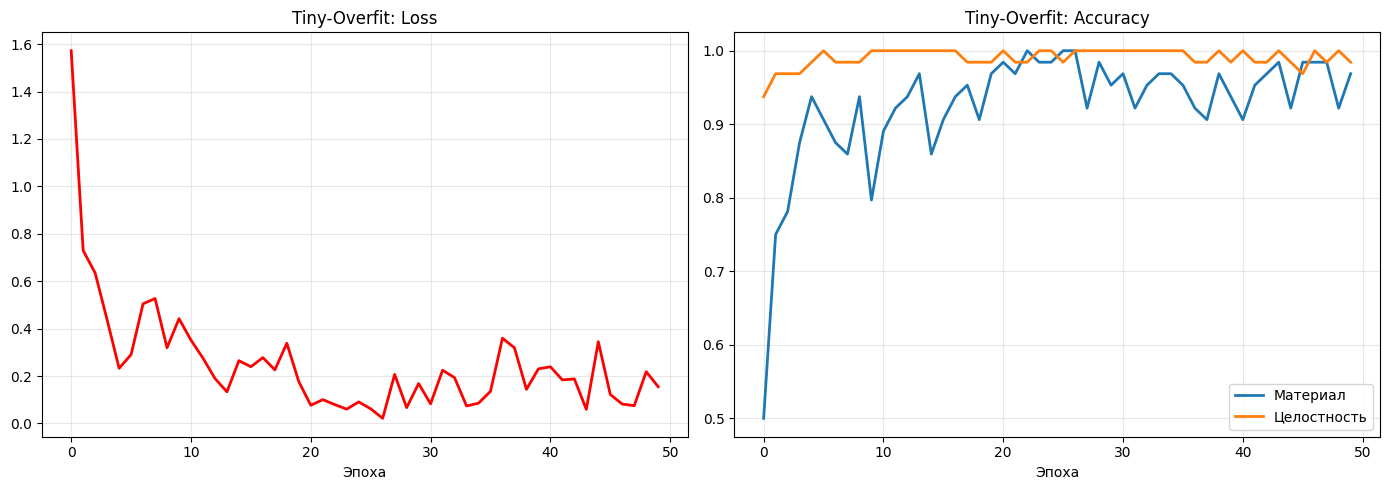


Итог: loss=0.1549  acc_mat=0.9688  acc_frag=0.9844
Переобучение неполное — проверь pipeline.


In [14]:
tiny_size    = 64
tiny_indices = list(range(min(tiny_size, len(train_ds))))
tiny_subset  = torch.utils.data.Subset(train_ds, tiny_indices)
tiny_loader  = DataLoader(tiny_subset, batch_size=BATCH_SIZE, shuffle=True)

tiny_model     = MultiTaskModel(num_material, num_fragm, backbone_name="resnet50", pretrained=True).to(DEVICE)
tiny_optimizer = optim.AdamW(tiny_model.parameters(), lr=3e-4, weight_decay=1e-4)

print(f"Tiny-subset: {len(tiny_subset)} примеров")

tiny_model.train()
tiny_losses, tiny_acc_mat, tiny_acc_frag = [], [], []

for epoch in range(50):
    ep_losses, ep_acc_mat, ep_acc_frag = [], [], []
    for imgs, tgts, msks, _ in tiny_loader:
        imgs, tgts, msks = imgs.to(DEVICE), tgts.to(DEVICE), msks.to(DEVICE)
        lm, lf = tiny_model(imgs)
        loss, _, _, acc_m, acc_f = compute_loss_and_metrics(lm, lf, tgts, msks)
        tiny_optimizer.zero_grad()
        loss.backward()
        tiny_optimizer.step()
        ep_losses.append(loss.item()); ep_acc_mat.append(acc_m); ep_acc_frag.append(acc_f)

    tiny_losses.append(np.mean(ep_losses))
    tiny_acc_mat.append(np.mean(ep_acc_mat))
    tiny_acc_frag.append(np.mean(ep_acc_frag))

    if epoch % 10 == 0 or epoch == 49:
        print(f"  Эпоха {epoch:2d}: loss={tiny_losses[-1]:.4f}  "
              f"acc_mat={tiny_acc_mat[-1]:.4f}  acc_frag={tiny_acc_frag[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(tiny_losses, color="red", linewidth=2)
axes[0].set_title("Tiny-Overfit: Loss"); axes[0].set_xlabel("Эпоха"); axes[0].grid(True, alpha=0.3)

axes[1].plot(tiny_acc_mat,  label="Материал",    linewidth=2)
axes[1].plot(tiny_acc_frag, label="Целостность",  linewidth=2)
axes[1].set_title("Tiny-Overfit: Accuracy"); axes[1].set_xlabel("Эпоха"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

overfit_ok = tiny_losses[-1] < 0.1 and tiny_acc_mat[-1] > 0.9
print(f"\nИтог: loss={tiny_losses[-1]:.4f}  acc_mat={tiny_acc_mat[-1]:.4f}  acc_frag={tiny_acc_frag[-1]:.4f}")
print("Переобучение достигнуто." if overfit_ok else "Переобучение неполное — проверь pipeline.")


# Задание 14 — Циклы train/eval

Реализуем `train_epoch` и `validate_epoch`. Ключевые отличия:
- train: `model.train()`, `optimizer.zero_grad()`, `loss.backward()`, `optimizer.step()`
- eval: `model.eval()`, `@torch.no_grad()`, без аугментаций в DataLoader
- Метрики считаются только по элементам с `mask == 1`

In [15]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    all_pred_mat, all_gt_mat, all_mask_mat     = [], [], []
    all_pred_frag, all_gt_frag, all_mask_frag  = [], [], []

    for images, targets, masks, _ in loader:
        images, targets, masks = images.to(device), targets.to(device), masks.to(device)

        logits_mat, logits_frag = model(images)
        loss, _, _, _, _ = compute_loss_and_metrics(logits_mat, logits_frag, targets, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(images)
        all_pred_mat.append(logits_mat.argmax(1).detach().cpu())
        all_gt_mat.append(targets[:, 0].detach().cpu())
        all_mask_mat.append(masks[:, 0].detach().cpu())
        all_pred_frag.append(logits_frag.argmax(1).detach().cpu())
        all_gt_frag.append(targets[:, 1].detach().cpu())
        all_mask_frag.append(masks[:, 1].detach().cpu())

    all_pred_mat  = torch.cat(all_pred_mat);  all_gt_mat  = torch.cat(all_gt_mat);  all_mask_mat  = torch.cat(all_mask_mat)
    all_pred_frag = torch.cat(all_pred_frag); all_gt_frag = torch.cat(all_gt_frag); all_mask_frag = torch.cat(all_mask_frag)
    v_mat  = all_mask_mat.bool();  v_frag = all_mask_frag.bool()
    acc_mat  = accuracy_score(all_gt_mat[v_mat],   all_pred_mat[v_mat])   if v_mat.sum()  > 0 else 0.0
    acc_frag = accuracy_score(all_gt_frag[v_frag], all_pred_frag[v_frag]) if v_frag.sum() > 0 else 0.0
    return total_loss / len(loader.dataset), acc_mat, acc_frag


@torch.no_grad()
def validate_epoch(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_pred_mat, all_gt_mat, all_mask_mat     = [], [], []
    all_pred_frag, all_gt_frag, all_mask_frag  = [], [], []

    for images, targets, masks, _ in loader:
        images, targets, masks = images.to(device), targets.to(device), masks.to(device)

        logits_mat, logits_frag = model(images)
        loss, _, _, _, _ = compute_loss_and_metrics(logits_mat, logits_frag, targets, masks)

        total_loss += loss.item() * len(images)
        all_pred_mat.append(logits_mat.argmax(1).cpu())
        all_gt_mat.append(targets[:, 0].cpu())
        all_mask_mat.append(masks[:, 0].cpu())
        all_pred_frag.append(logits_frag.argmax(1).cpu())
        all_gt_frag.append(targets[:, 1].cpu())
        all_mask_frag.append(masks[:, 1].cpu())

    all_pred_mat  = torch.cat(all_pred_mat);  all_gt_mat  = torch.cat(all_gt_mat);  all_mask_mat  = torch.cat(all_mask_mat)
    all_pred_frag = torch.cat(all_pred_frag); all_gt_frag = torch.cat(all_gt_frag); all_mask_frag = torch.cat(all_mask_frag)
    v_mat  = all_mask_mat.bool();  v_frag = all_mask_frag.bool()
    acc_mat  = accuracy_score(all_gt_mat[v_mat],   all_pred_mat[v_mat])   if v_mat.sum()  > 0 else 0.0
    acc_frag = accuracy_score(all_gt_frag[v_frag], all_pred_frag[v_frag]) if v_frag.sum() > 0 else 0.0
    f1_mat   = f1_score(all_gt_mat[v_mat],   all_pred_mat[v_mat],   average="macro") if v_mat.sum()  > 0 else 0.0
    f1_frag  = f1_score(all_gt_frag[v_frag], all_pred_frag[v_frag], average="macro") if v_frag.sum() > 0 else 0.0
    return total_loss / len(loader.dataset), acc_mat, acc_frag, f1_mat, f1_frag


# Задание 15 — Конфиг и планировщик

Инициализируем модель, оптимизатор и scheduler. Фиксируем baseline-конфиг:
**AdamW** (lr=3e-4, wd=1e-4) + **CosineAnnealingLR** (T_max=EPOCHS).

Выводим дисбаланс классов и строим график изменения learning rate по эпохам.

Конфигурация baseline:
  Optimizer:  AdamW  lr=3e-4  weight_decay=1e-4
  Scheduler:  CosineAnnealingLR  T_max=30
  Эпохи:      30
  Batch size: 8
  Устройство: mps

Дисбаланс материала: 49.4x
norm_material
керамика    346
фаянс       175
фарфор      127
прочее       15
глина        13
стекло        7

Распределение целостности:
norm_fragm
фрагмент    629
целый        54


/Users/baranczov/Downloads/Project_DL/.dl_task/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


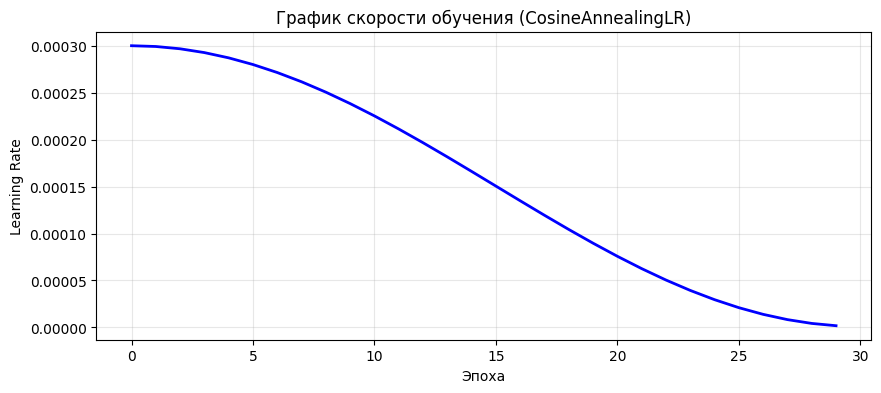

In [16]:
model     = MultiTaskModel(num_material, num_fragm, backbone_name="resnet50", pretrained=True).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print("Конфигурация baseline:")
print(f"  Optimizer:  AdamW  lr=3e-4  weight_decay=1e-4")
print(f"  Scheduler:  CosineAnnealingLR  T_max={EPOCHS}")
print(f"  Эпохи:      {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Устройство: {DEVICE}")

mat_dist = train_df["norm_material"].value_counts()
print(f"\nДисбаланс материала: {mat_dist.max() / mat_dist.min():.1f}x")
print(mat_dist.to_string())

print(f"\nРаспределение целостности:")
print(train_df["norm_fragm"].value_counts().to_string())

# График learning rate (без изменения состояния оптимизатора)
_sched_tmp = optim.lr_scheduler.CosineAnnealingLR(
    optim.AdamW([torch.zeros(1)], lr=3e-4), T_max=EPOCHS, eta_min=1e-6
)
lrs = []
for _ in range(EPOCHS):
    lrs.append(_sched_tmp.get_last_lr()[0])
    _sched_tmp.step()

plt.figure(figsize=(10, 4))
plt.plot(lrs, linewidth=2, color="blue")
plt.title("График скорости обучения (CosineAnnealingLR)")
plt.xlabel("Эпоха"); plt.ylabel("Learning Rate"); plt.grid(True, alpha=0.3)
plt.show()


# Задание 16 — Чекпоинты и логирование

Сохраняем `config.json` со всеми параметрами (словари классов, пороги шаблона).
Чекпоинт содержит: `model_state_dict`, `optimizer_state_dict`, `scheduler_state_dict`,
номер эпохи, метрики. Храним `best.pt` (по `mean_macroF1`) и `last.pt`.

In [17]:
checkpoint_dir = "artifacts/checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

mat_classes   = train_ds.mat_classes
fragm_classes = train_ds.fragm_classes

template_config = {
    "fields":          ["material", "fragm", "name"],
    "required_fields": ["fragm", "name"],
    "optional_fields": ["material"],
    "thresholds":      THRESHOLDS,
}

config = {
    "backbone":              "resnet50",
    "image_size":            IMAGE_SIZE,
    "num_material_classes":  num_material,
    "num_fragm_classes":     num_fragm,
    "material_classes":      mat_classes,
    "fragm_classes":         fragm_classes,
    "mat_to_idx":            train_ds.mat_to_idx,
    "fragm_to_idx":          train_ds.fragm_to_idx,
    "optimizer":             "AdamW",
    "learning_rate":         3e-4,
    "weight_decay":          1e-4,
    "scheduler":             "CosineAnnealingLR",
    "T_max":                 EPOCHS,
    "num_epochs":            EPOCHS,
    "batch_size":            BATCH_SIZE,
    "template_config":       template_config,
}

config_path = os.path.join(checkpoint_dir, "config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
print(f"Конфиг сохранён: {config_path}")


def save_checkpoint(model, optimizer, scheduler, epoch, metrics, filename, extra_data=None):
    checkpoint = {
        "epoch":                epoch,
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "metrics":              metrics,
        "config":               config,
    }
    if extra_data:
        checkpoint.update(extra_data)
    torch.save(checkpoint, os.path.join(checkpoint_dir, filename))


def load_checkpoint(filename, model, optimizer=None, scheduler=None):
    checkpoint = torch.load(
        os.path.join(checkpoint_dir, filename),
        map_location=DEVICE,
        weights_only=False,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scheduler and checkpoint.get("scheduler_state_dict"):
        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    return checkpoint


train_log   = []
best_val_f1 = 0.0
best_epoch  = 0
print("Инфраструктура чекпоинтов готова.")


Конфиг сохранён: artifacts/checkpoints/config.json
Инфраструктура чекпоинтов готова.


# Задание 17 — Обучение и оценка

Запускаем полный цикл обучения на `EPOCHS` эпохах. После каждой эпохи:
- Сохраняем `last.pt`
- Обновляем `best.pt` если `mean_macroF1` улучшился

После обучения: строим кривые loss/accuracy/F1, загружаем лучшую модель,
выводим confusion matrix и classification report для обоих полей.

In [18]:
print(f"Обучение на {DEVICE}  |  train={len(train_ds)}, val={len(val_ds)}")

for epoch in range(EPOCHS):
    train_loss, train_acc_mat, train_acc_frag = train_epoch(model, train_loader, optimizer, DEVICE)
    val_loss, val_acc_mat, val_acc_frag, val_f1_mat, val_f1_frag = validate_epoch(model, val_loader, DEVICE)
    scheduler.step()

    mean_val_f1 = (val_f1_mat + val_f1_frag) / 2

    train_log.append({
        "epoch": epoch + 1,
        "train_loss": train_loss, "train_acc_mat": train_acc_mat, "train_acc_frag": train_acc_frag,
        "val_loss": val_loss, "val_acc_mat": val_acc_mat, "val_acc_frag": val_acc_frag,
        "val_f1_mat": val_f1_mat, "val_f1_frag": val_f1_frag, "mean_val_f1": mean_val_f1,
    })

    print(f"[{epoch+1:2d}/{EPOCHS}]  "
          f"T_loss={train_loss:.4f}  V_loss={val_loss:.4f}  "
          f"acc_mat={val_acc_mat:.4f}  acc_frag={val_acc_frag:.4f}  "
          f"f1_mat={val_f1_mat:.4f}  f1_frag={val_f1_frag:.4f}  "
          f"mean_f1={mean_val_f1:.4f}")

    save_checkpoint(model, optimizer, scheduler, epoch,
                    {"val_f1_mat": val_f1_mat, "val_f1_frag": val_f1_frag, "mean_val_f1": mean_val_f1},
                    "last.pt")

    if mean_val_f1 > best_val_f1:
        best_val_f1 = mean_val_f1
        best_epoch  = epoch + 1
        save_checkpoint(model, optimizer, scheduler, epoch,
                        {"val_f1_mat": val_f1_mat, "val_f1_frag": val_f1_frag, "mean_val_f1": mean_val_f1},
                        "best.pt")
        print(f"  ↑ Новая лучшая модель  mean_f1={mean_val_f1:.4f}")

print(f"\nОбучение завершено. Лучшая эпоха: {best_epoch}, mean_F1={best_val_f1:.4f}")

log_df = pd.DataFrame(train_log)
log_df.to_csv("artifacts/reports/training_log.csv", index=False)
print("Лог: artifacts/reports/training_log.csv")


Обучение на mps  |  train=683, val=228
[ 1/30]  T_loss=1.2244  V_loss=1.3565  acc_mat=0.7237  acc_frag=0.9123  f1_mat=0.3510  f1_frag=0.4771  mean_f1=0.4141
  ↑ Новая лучшая модель  mean_f1=0.4141
[ 2/30]  T_loss=1.0283  V_loss=1.2109  acc_mat=0.6184  acc_frag=0.9167  f1_mat=0.3068  f1_frag=0.4783  mean_f1=0.3925
[ 3/30]  T_loss=0.9215  V_loss=1.0452  acc_mat=0.7895  acc_frag=0.8465  f1_mat=0.3979  f1_frag=0.5507  mean_f1=0.4743
  ↑ Новая лучшая модель  mean_f1=0.4743
[ 4/30]  T_loss=0.8489  V_loss=1.0497  acc_mat=0.7456  acc_frag=0.9254  f1_mat=0.3760  f1_frag=0.6403  mean_f1=0.5081
  ↑ Новая лучшая модель  mean_f1=0.5081
[ 5/30]  T_loss=0.8176  V_loss=1.1216  acc_mat=0.7675  acc_frag=0.9211  f1_mat=0.3893  f1_frag=0.6575  mean_f1=0.5234
  ↑ Новая лучшая модель  mean_f1=0.5234
[ 6/30]  T_loss=0.6834  V_loss=1.2327  acc_mat=0.7237  acc_frag=0.8816  f1_mat=0.3949  f1_frag=0.5822  mean_f1=0.4885
[ 7/30]  T_loss=0.7061  V_loss=1.6760  acc_mat=0.5570  acc_frag=0.8772  f1_mat=0.3031  f1_fra

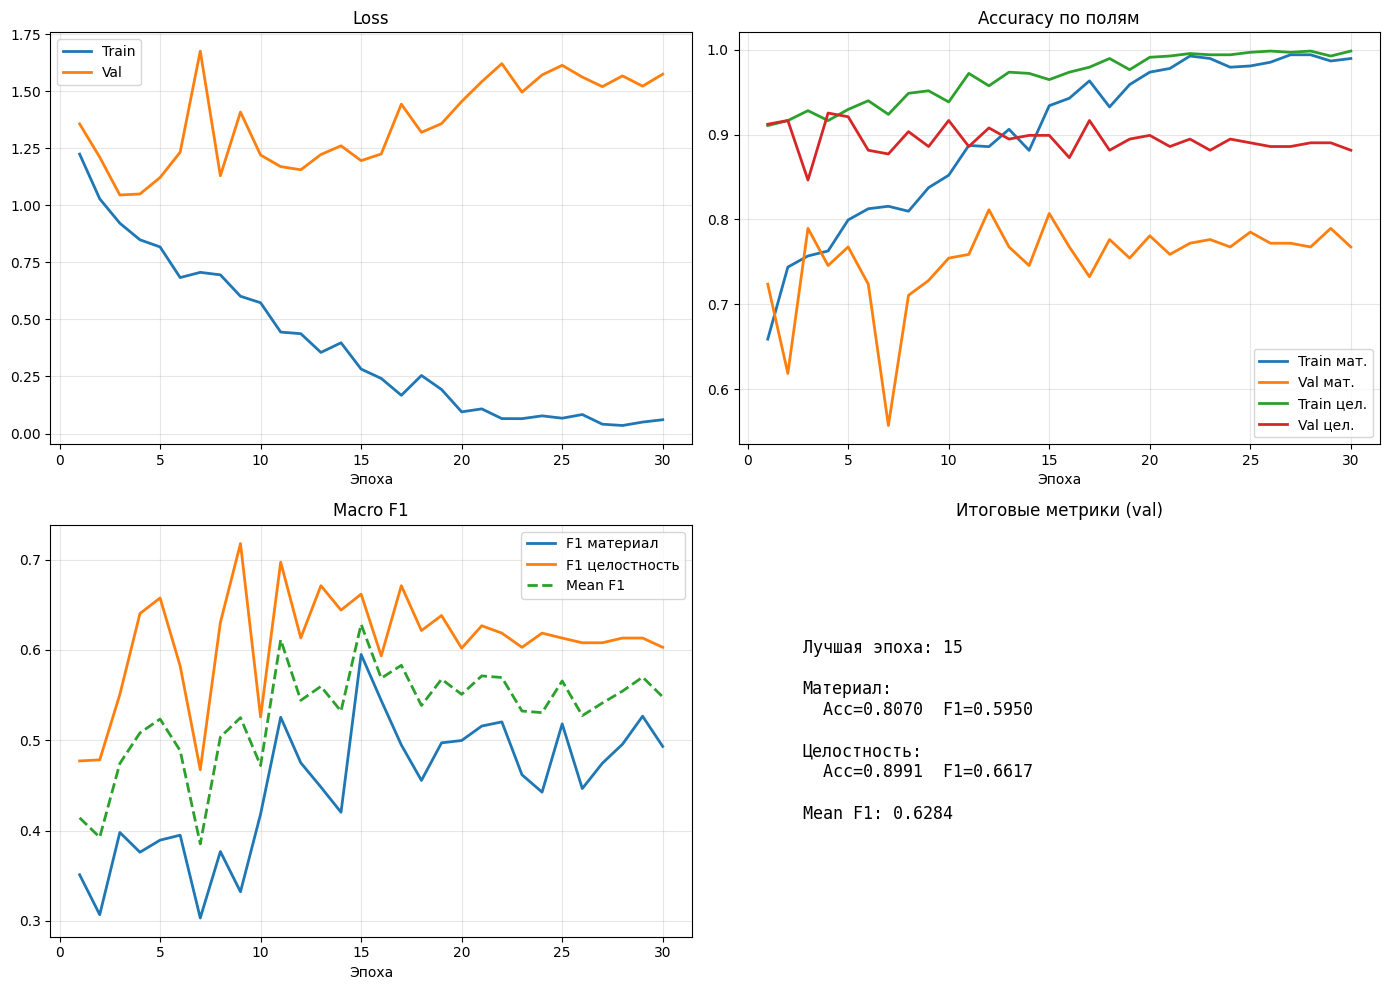

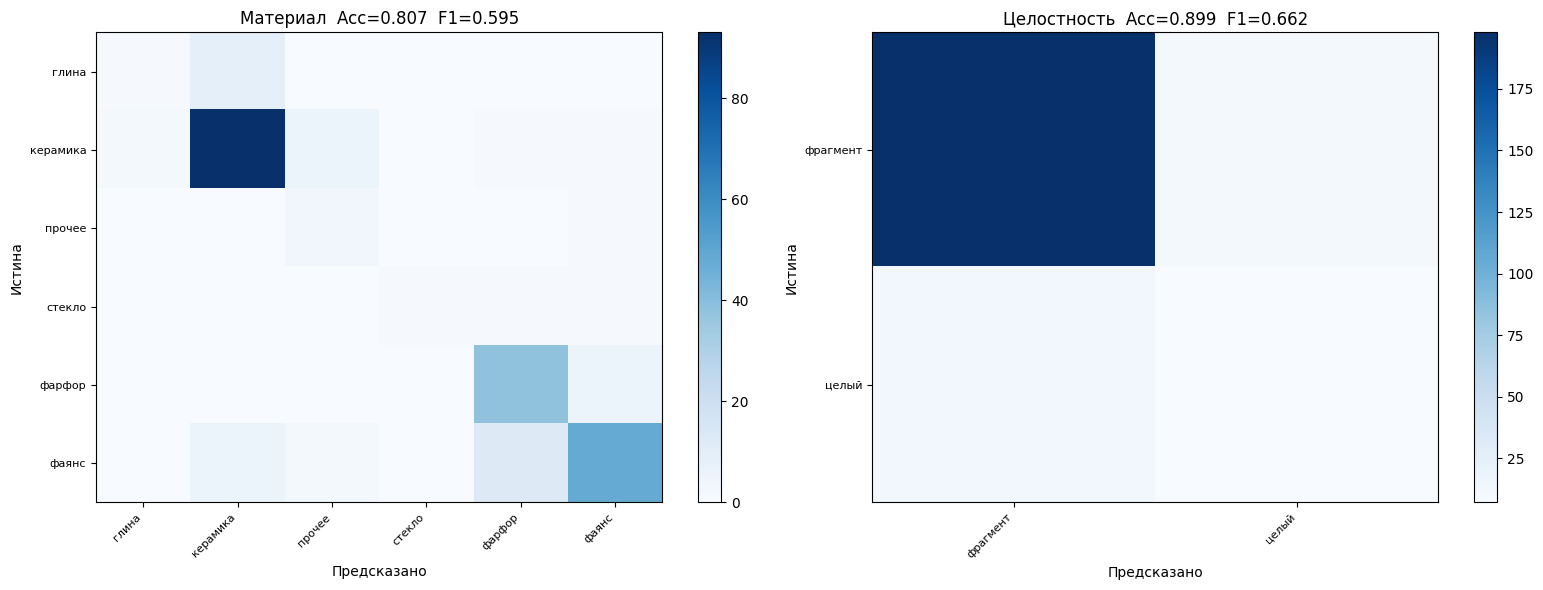

Отчёт — Материал:
              precision    recall  f1-score   support

       глина       0.33      0.11      0.17         9
    керамика       0.88      0.91      0.89       102
      прочее       0.30      0.75      0.43         4
      стекло       1.00      0.33      0.50         3
      фарфор       0.73      0.88      0.80        43
       фаянс       0.86      0.72      0.78        67

    accuracy                           0.81       228
   macro avg       0.68      0.62      0.59       228
weighted avg       0.81      0.81      0.80       228

Отчёт — Целостность:
              precision    recall  f1-score   support

    фрагмент       0.94      0.95      0.95       209
       целый       0.39      0.37      0.38        19

    accuracy                           0.90       228
   macro avg       0.67      0.66      0.66       228
weighted avg       0.90      0.90      0.90       228

5 лучших классов материала:
  керамика            : 0.912
  фарфор              : 0.884
  п

In [19]:
log_df = pd.read_csv("artifacts/reports/training_log.csv")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(log_df["epoch"], log_df["train_loss"], label="Train", linewidth=2)
axes[0, 0].plot(log_df["epoch"], log_df["val_loss"],   label="Val",   linewidth=2)
axes[0, 0].set_title("Loss"); axes[0, 0].set_xlabel("Эпоха"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(log_df["epoch"], log_df["train_acc_mat"],  label="Train мат.",  linewidth=2)
axes[0, 1].plot(log_df["epoch"], log_df["val_acc_mat"],    label="Val мат.",    linewidth=2)
axes[0, 1].plot(log_df["epoch"], log_df["train_acc_frag"], label="Train цел.",  linewidth=2)
axes[0, 1].plot(log_df["epoch"], log_df["val_acc_frag"],   label="Val цел.",    linewidth=2)
axes[0, 1].set_title("Accuracy по полям"); axes[0, 1].set_xlabel("Эпоха"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(log_df["epoch"], log_df["val_f1_mat"],  label="F1 материал",    linewidth=2)
axes[1, 0].plot(log_df["epoch"], log_df["val_f1_frag"], label="F1 целостность", linewidth=2)
axes[1, 0].plot(log_df["epoch"], log_df["mean_val_f1"], label="Mean F1",        linewidth=2, linestyle="--")
axes[1, 0].set_title("Macro F1"); axes[1, 0].set_xlabel("Эпоха"); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis("off")
best_row = log_df[log_df["epoch"] == best_epoch].iloc[0]
summary  = (f"Лучшая эпоха: {best_epoch}\n\n"
            f"Материал:\n  Acc={best_row['val_acc_mat']:.4f}  F1={best_row['val_f1_mat']:.4f}\n\n"
            f"Целостность:\n  Acc={best_row['val_acc_frag']:.4f}  F1={best_row['val_f1_frag']:.4f}\n\n"
            f"Mean F1: {best_row['mean_val_f1']:.4f}")
axes[1, 1].text(0.1, 0.5, summary, transform=axes[1, 1].transAxes,
                fontsize=12, va="center", fontfamily="monospace")
axes[1, 1].set_title("Итоговые метрики (val)")
plt.tight_layout(); plt.show()

# ── Confusion matrix ───────────────────────────────────────────────
load_checkpoint("best.pt", model)
model.eval()


@torch.no_grad()
def get_predictions(loader):
    model.eval()
    all_pred_mat, all_gt_mat, all_pred_frag, all_gt_frag = [], [], [], []
    for images, targets, masks, _ in loader:
        lm, lf = model(images.to(DEVICE))
        all_pred_mat.append(lm.argmax(1).cpu()); all_gt_mat.append(targets[:, 0])
        all_pred_frag.append(lf.argmax(1).cpu()); all_gt_frag.append(targets[:, 1])
    return (torch.cat(all_pred_mat), torch.cat(all_gt_mat),
            torch.cat(all_pred_frag), torch.cat(all_gt_frag))


pred_mat, gt_mat, pred_frag, gt_frag = get_predictions(val_loader)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, cm_data, classes, title in zip(
    axes,
    [confusion_matrix(gt_mat, pred_mat), confusion_matrix(gt_frag, pred_frag)],
    [mat_classes, fragm_classes],
    [f"Материал  Acc={best_row['val_acc_mat']:.3f}  F1={best_row['val_f1_mat']:.3f}",
     f"Целостность  Acc={best_row['val_acc_frag']:.3f}  F1={best_row['val_f1_frag']:.3f}"],
):
    im = ax.imshow(cm_data, cmap="Blues", aspect="auto")
    ax.set_title(title); ax.set_xlabel("Предсказано"); ax.set_ylabel("Истина")
    if len(classes) <= 10:
        ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
        ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes, fontsize=8)
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

print("Отчёт — Материал:")
print(classification_report(gt_mat, pred_mat, target_names=mat_classes, zero_division=0))
print("Отчёт — Целостность:")
print(classification_report(gt_frag, pred_frag, target_names=fragm_classes, zero_division=0))

mat_class_acc = {
    cls: (pred_mat[gt_mat == i] == i).float().mean().item()
    for i, cls in enumerate(mat_classes) if (gt_mat == i).sum() > 0
}
print("5 лучших классов материала:")
for cls, acc in sorted(mat_class_acc.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {cls:20s}: {acc:.3f}")
print("5 худших классов материала:")
for cls, acc in sorted(mat_class_acc.items(), key=lambda x: x[1])[:5]:
    print(f"  {cls:20s}: {acc:.3f}")


# Задание 18 — Инференс и генерация auto_description

Реализуем инференс-функции: `inference_single_image` возвращает предсказания и уверенности,
`run_inference_on_dataframe` обходит переданный DataFrame и сохраняет CSV с колонками:
`image_file`, `auto_description`, `pred_material`, `pred_fragm`, `conf_material`, `conf_fragm`.

In [20]:
@torch.no_grad()
def inference_single_image(model, image_path, transform, device):
    img_array    = np.fromfile(image_path, dtype=np.uint8)
    image        = cv2.cvtColor(cv2.imdecode(img_array, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    image_tensor = transform(image=image)["image"].unsqueeze(0).to(device)

    logits_mat, logits_frag = model(image_tensor)
    probs_mat  = F.softmax(logits_mat,  dim=1)
    probs_frag = F.softmax(logits_frag, dim=1)

    conf_mat,  pred_mat_idx  = probs_mat.max(dim=1)
    conf_frag, pred_frag_idx = probs_frag.max(dim=1)

    preds = {
        "material": mat_classes[pred_mat_idx.item()],
        "fragm":    fragm_classes[pred_frag_idx.item()],
        "name":     "предмет",
    }
    confs = {
        "material": conf_mat.item(),
        "fragm":    conf_frag.item(),
        "name":     1.0,
    }
    return preds, confs


def run_inference_on_dataframe(model, df, transform, device, output_csv):
    results = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Инференс"):
        img_path = row["full_image_path"]
        try:
            preds, confs = inference_single_image(model, img_path, transform, device)
            description  = generate_auto_description(preds, confs, THRESHOLDS)
            results.append({
                "image_file":       os.path.basename(img_path),
                "auto_description": description,
                "pred_material":    preds["material"],
                "pred_fragm":       preds["fragm"],
                "conf_material":    round(confs["material"], 4),
                "conf_fragm":       round(confs["fragm"],    4),
            })
        except Exception as e:
            results.append({
                "image_file": os.path.basename(img_path),
                "auto_description": "Ошибка обработки изображения",
                "pred_material": "ошибка", "pred_fragm": "ошибка",
                "conf_material": 0.0,       "conf_fragm": 0.0,
            })

    result_df = pd.DataFrame(results)
    result_df.to_csv(output_csv, index=False)
    print(f"Сохранено: {output_csv}  ({len(result_df)} строк)")
    return result_df


load_checkpoint("best.pt", model)

result_df = run_inference_on_dataframe(
    model, val_df.head(20), val_transform, DEVICE,
    "artifacts/preds/val_predictions.csv",
)

print("\nПримеры предсказаний:")
display(result_df[["image_file", "auto_description"]].head(10))

low_conf = result_df[(result_df["conf_material"] < 0.5) | (result_df["conf_fragm"] < 0.5)]
if not low_conf.empty:
    row = low_conf.iloc[0]
    print(f"\nПример низкой уверенности:")
    print(f"  Файл:     {row['image_file']}")
    print(f"  Материал: {row['pred_material']} (conf={row['conf_material']:.3f})")
    print(f"  Целость:  {row['pred_fragm']} (conf={row['conf_fragm']:.3f})")
    print(f"  Описание: {row['auto_description']}")
else:
    print("\nПредсказаний с низкой уверенностью не найдено.")


Инференс: 100%|██████████| 20/20 [00:01<00:00, 12.37it/s]

Сохранено: artifacts/preds/val_predictions.csv  (20 строк)

Примеры предсказаний:


,image_file,auto_description
0,М102-2012-1-0496_orig.jpg,"Фрагмент типа 'предмет', материал: керамика."
1,М102-2012-1-0529_orig.jpg,"Фрагмент типа 'предмет', материал: керамика."
2,М102-2012-1-0827_orig.jpg,"Фрагмент типа 'предмет', возможный материал: ф..."
3,М102-2012-1-0837_orig.jpg,"Фрагмент типа 'предмет', возможный материал: ф..."
4,М102-2012-1-0843_orig.jpg,Фрагмент типа 'предмет'
5,М102-2012-1-0942_orig.jpg,"Фрагмент типа 'предмет', материал: керамика."
6,М102-2012-2-1267_orig.jpg,"Фрагмент типа 'предмет', материал: фаянс."
7,М102-2012-2-1314_orig.jpg,"Фрагмент типа 'предмет', возможный материал: ф..."
8,М102-2012-2-1361_orig.jpg,"Фрагмент типа 'предмет', возможный материал: ф..."
9,Мич11-ш01-005_orig.jpg,"Фрагмент типа 'предмет', материал: керамика."



Пример низкой уверенности:
  Файл:     М102-2012-1-0827_orig.jpg
  Материал: фаянс (conf=0.431)
  Целость:  фрагмент (conf=0.999)
  Описание: Фрагмент типа 'предмет', возможный материал: фаянс.


# Задание 19 — Ablation Study

Сравниваем 4 конфигурации (все используют один `val_inner`, один seed):

| # | Эксперимент | Что меняем |
|---|-------------|------------|
| 1 | baseline resnet50 224 + aug | — |
| 2 | resnet50 384 + aug | размер входа |
| 3 | resnet50 224, без аугментаций | выключены train-aug |
| 4 | resnet50 224 + aug + class weights | взвешенный loss |

In [21]:
ablation_results = []

# ── Эксп. 1: baseline ─────────────────────────────────────────────
ablation_results.append({
    "experiment":   "resnet50_aug_224",
    "backbone":     "resnet50",
    "image_size":   224,
    "augmentations": "да",
    "val_mean_f1":  best_row["mean_val_f1"],
    "val_acc_mat":  best_row["val_acc_mat"],
    "val_acc_frag": best_row["val_acc_frag"],
})

# ── Эксп. 2: размер 384 ───────────────────────────────────────────
print("Эксперимент 2: размер 384...")
IMAGE_SIZE_384  = 384
resize_pad_384  = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE_384),
    A.PadIfNeeded(min_height=IMAGE_SIZE_384, min_width=IMAGE_SIZE_384,
                  border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255]),
])
train_transform_384 = A.Compose([
    resize_pad_384,
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255]),
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.5),
    A.HueSaturationValue(hue_shift_limit=5, sat_shift_limit=10, val_shift_limit=10, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
val_transform_384 = A.Compose([
    resize_pad_384,
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
train_ds_384     = ArchaeologyDataset(train_df, transform=train_transform_384)
val_ds_384       = ArchaeologyDataset(val_df,   transform=val_transform_384)
train_loader_384 = DataLoader(train_ds_384, batch_size=4, shuffle=True)
val_loader_384   = DataLoader(val_ds_384,   batch_size=4, shuffle=False)
model_384     = MultiTaskModel(num_material, num_fragm, backbone_name="resnet50", pretrained=True).to(DEVICE)
optimizer_384 = optim.AdamW(model_384.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_384 = optim.lr_scheduler.CosineAnnealingLR(optimizer_384, T_max=EPOCHS, eta_min=1e-6)
best_f1_384, best_acc_mat_384, best_acc_frag_384 = 0.0, 0.0, 0.0
for epoch in range(EPOCHS):
    train_epoch(model_384, train_loader_384, optimizer_384, DEVICE)
    _, val_acc_mat, val_acc_frag, val_f1_mat, val_f1_frag = validate_epoch(model_384, val_loader_384, DEVICE)
    scheduler_384.step()
    mean_f1 = (val_f1_mat + val_f1_frag) / 2
    if mean_f1 > best_f1_384:
        best_f1_384, best_acc_mat_384, best_acc_frag_384 = mean_f1, val_acc_mat, val_acc_frag
ablation_results.append({
    "experiment": "resnet50_aug_384", "backbone": "resnet50", "image_size": 384,
    "augmentations": "да", "val_mean_f1": best_f1_384,
    "val_acc_mat": best_acc_mat_384, "val_acc_frag": best_acc_frag_384,
})

# ── Эксп. 3: без аугментаций ──────────────────────────────────────
print("Эксперимент 3: без аугментаций...")
train_transform_noaug = A.Compose([
    resize_pad,
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])
train_ds_noaug     = ArchaeologyDataset(train_df, transform=train_transform_noaug)
train_loader_noaug = DataLoader(train_ds_noaug, batch_size=BATCH_SIZE, shuffle=True)
model_noaug     = MultiTaskModel(num_material, num_fragm, backbone_name="resnet50", pretrained=True).to(DEVICE)
optimizer_noaug = optim.AdamW(model_noaug.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_noaug = optim.lr_scheduler.CosineAnnealingLR(optimizer_noaug, T_max=EPOCHS, eta_min=1e-6)
best_f1_noaug, best_acc_mat_noaug, best_acc_frag_noaug = 0.0, 0.0, 0.0
for epoch in range(EPOCHS):
    train_epoch(model_noaug, train_loader_noaug, optimizer_noaug, DEVICE)
    _, val_acc_mat, val_acc_frag, val_f1_mat, val_f1_frag = validate_epoch(model_noaug, val_loader, DEVICE)
    scheduler_noaug.step()
    mean_f1 = (val_f1_mat + val_f1_frag) / 2
    if mean_f1 > best_f1_noaug:
        best_f1_noaug, best_acc_mat_noaug, best_acc_frag_noaug = mean_f1, val_acc_mat, val_acc_frag
ablation_results.append({
    "experiment": "resnet50_noaug_224", "backbone": "resnet50", "image_size": 224,
    "augmentations": "нет", "val_mean_f1": best_f1_noaug,
    "val_acc_mat": best_acc_mat_noaug, "val_acc_frag": best_acc_frag_noaug,
})

# ── Эксп. 4: class weights ────────────────────────────────────────
print("Эксперимент 4: взвешенный loss...")
mat_counts   = train_df["norm_material"].value_counts()
frag_counts  = train_df["norm_fragm"].value_counts()
mat_weights  = 1.0 / torch.tensor([mat_counts.get(c, 1)  for c in mat_classes],   dtype=torch.float32)
frag_weights = 1.0 / torch.tensor([frag_counts.get(c, 1) for c in fragm_classes], dtype=torch.float32)
mat_weights  = mat_weights  / mat_weights.sum()  * len(mat_classes)
frag_weights = frag_weights / frag_weights.sum() * len(fragm_classes)

def compute_weighted_loss(logits_mat, logits_frag, targets, masks):
    target_mat  = targets[:, 0]; mask_mat  = masks[:, 0]
    target_frag = targets[:, 1]; mask_frag = masks[:, 1]
    loss_mat  = (F.cross_entropy(logits_mat,  target_mat,  weight=mat_weights.to(DEVICE),  reduction="none") * mask_mat ).sum() / (mask_mat.sum()  + 1e-8)
    loss_frag = (F.cross_entropy(logits_frag, target_frag, weight=frag_weights.to(DEVICE), reduction="none") * mask_frag).sum() / (mask_frag.sum() + 1e-8)
    total_loss = loss_mat + loss_frag
    pred_mat  = logits_mat.argmax(1);  pred_frag = logits_frag.argmax(1)
    v_mat = mask_mat.bool(); v_frag = mask_frag.bool()
    acc_mat  = accuracy_score(target_mat[v_mat].cpu(),   pred_mat[v_mat].cpu())   if v_mat.sum()  > 0 else 0.0
    acc_frag = accuracy_score(target_frag[v_frag].cpu(), pred_frag[v_frag].cpu()) if v_frag.sum() > 0 else 0.0
    return total_loss, loss_mat.item(), loss_frag.item(), acc_mat, acc_frag

def train_epoch_weighted(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    for images, targets, masks, _ in loader:
        images, targets, masks = images.to(device), targets.to(device), masks.to(device)
        lm, lf = model(images)
        loss, *_ = compute_weighted_loss(lm, lf, targets, masks)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * len(images)
    return total_loss / len(loader.dataset)

model_weighted     = MultiTaskModel(num_material, num_fragm, backbone_name="resnet50", pretrained=True).to(DEVICE)
optimizer_weighted = optim.AdamW(model_weighted.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler_weighted = optim.lr_scheduler.CosineAnnealingLR(optimizer_weighted, T_max=EPOCHS, eta_min=1e-6)
best_f1_w, best_acc_mat_w, best_acc_frag_w = 0.0, 0.0, 0.0
for epoch in range(EPOCHS):
    train_epoch_weighted(model_weighted, train_loader, optimizer_weighted, DEVICE)
    _, val_acc_mat, val_acc_frag, val_f1_mat, val_f1_frag = validate_epoch(model_weighted, val_loader, DEVICE)
    scheduler_weighted.step()
    mean_f1 = (val_f1_mat + val_f1_frag) / 2
    if mean_f1 > best_f1_w:
        best_f1_w, best_acc_mat_w, best_acc_frag_w = mean_f1, val_acc_mat, val_acc_frag
ablation_results.append({
    "experiment": "resnet50_classweights_224", "backbone": "resnet50", "image_size": 224,
    "augmentations": "да", "val_mean_f1": best_f1_w,
    "val_acc_mat": best_acc_mat_w, "val_acc_frag": best_acc_frag_w,
})

# ── Итоги ─────────────────────────────────────────────────────────
ablation_df = pd.DataFrame(ablation_results)
print("\nRezultaty Ablation Study:")
display(ablation_df)
ablation_df.to_csv("artifacts/reports/ablation_study.csv", index=False)

best_exp = ablation_df.loc[ablation_df["val_mean_f1"].idxmax()]
print(f"\nЛучший эксперимент: {best_exp['experiment']}  mean_F1={best_exp['val_mean_f1']:.4f}")
baseline_f1 = ablation_df["val_mean_f1"].iloc[0]
for _, row in ablation_df.iterrows():
    delta = row["val_mean_f1"] - baseline_f1
    sign  = "+" if delta >= 0 else ""
    print(f"  {row['experiment']:35s}  mean_f1={row['val_mean_f1']:.4f}  ({sign}{delta:.4f})")


/var/folders/f9/07xx41b54m3d8sppgndj5vh80000gn/T/ipykernel_26655/1557711230.py:19: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE_384, min_width=IMAGE_SIZE_384,
/var/folders/f9/07xx41b54m3d8sppgndj5vh80000gn/T/ipykernel_26655/1557711230.py:25: UserWarning: Argument(s) 'value' are not valid for transform Rotate
  A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_CONSTANT, value=[255, 255, 255]),


Эксперимент 2: размер 384...
Эксперимент 3: без аугментаций...
Эксперимент 4: взвешенный loss...

Rezultaty Ablation Study:


,experiment,backbone,image_size,augmentations,val_mean_f1,val_acc_mat,val_acc_frag
0,resnet50_aug_224,resnet50,224,да,0.628368,0.807018,0.899123
1,resnet50_aug_384,resnet50,384,да,0.565312,0.776316,0.903509
2,resnet50_noaug_224,resnet50,224,нет,0.580853,0.785088,0.899123
3,resnet50_classweights_224,resnet50,224,да,0.603501,0.719298,0.877193



Лучший эксперимент: resnet50_aug_224  mean_F1=0.6284
  resnet50_aug_224                     mean_f1=0.6284  (+0.0000)
  resnet50_aug_384                     mean_f1=0.5653  (-0.0631)
  resnet50_noaug_224                   mean_f1=0.5809  (-0.0475)
  resnet50_classweights_224            mean_f1=0.6035  (-0.0249)


# Задание 20 + 21 — Финальная оценка и итог

Оцениваем лучшую модель на **test_open** (blind-подвыборка, не использовалась для подбора
гиперпараметров). Запускаем инференс по всем изображениям тестовой части,
выводим 5 удачных и 5 неудачных предсказаний.

In [22]:
test_ds     = ArchaeologyDataset(test_df, transform=val_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

load_checkpoint("best.pt", model)
test_loss, test_acc_mat, test_acc_frag, test_f1_mat, test_f1_frag = validate_epoch(
    model, test_loader, DEVICE
)
mean_test_f1 = (test_f1_mat + test_f1_frag) / 2

print("Финальные метрики на test_open:")
print(f"  Материал:    Acc={test_acc_mat:.4f}  F1={test_f1_mat:.4f}")
print(f"  Целостность: Acc={test_acc_frag:.4f}  F1={test_f1_frag:.4f}")
print(f"  Mean F1:     {mean_test_f1:.4f}")

test_result_df = run_inference_on_dataframe(
    model, test_df, val_transform, DEVICE,
    "artifacts/preds/test_open_predictions.csv",
)

print("\n5 удачных предсказаний (высокая уверенность по материалу):")
for _, row in test_result_df.nlargest(5, "conf_material").iterrows():
    print(f"  {row['image_file']}: {row['auto_description']}")

print("\n5 неудачных предсказаний (низкая уверенность по материалу):")
for _, row in test_result_df.nsmallest(5, "conf_material").iterrows():
    print(f"  {row['image_file']}: {row['auto_description']}")

print("\n" + "=" * 60)
print("ИТОГОВАЯ СВОДКА")
print("=" * 60)
print(f"  Поля:       material ({num_material} кл.), fragm ({num_fragm} кл.)")
print(f"  group_key:  'code'")
print(f"  Разбивка:   train={len(train_df)} / val={len(val_df)} / test={len(test_df)}")
print(f"  Backbone:   ResNet50 (ImageNet pretrained)")
print(f"  Вход:       {IMAGE_SIZE}×{IMAGE_SIZE}")
print(f"  Aug (train): HFlip, Rotate±20°, BrightnessContrast, HueSat")
print(f"  Optimizer:  AdamW  lr=3e-4  wd=1e-4")
print(f"  Scheduler:  CosineAnnealingLR  T_max={EPOCHS}")
print(f"  Best val F1: {best_val_f1:.4f}  (эпоха {best_epoch})")
print(f"  Test F1:     {mean_test_f1:.4f}")


Финальные метрики на test_open:
  Материал:    Acc=0.7763  F1=0.4783
  Целостность: Acc=0.9211  F1=0.6975
  Mean F1:     0.5879


Инференс: 100%|██████████| 228/228 [00:09<00:00, 24.74it/s]

Сохранено: artifacts/preds/test_open_predictions.csv  (228 строк)

5 удачных предсказаний (высокая уверенность по материалу):
  КБ-2014-Р1-1508_orig.jpg: Фрагмент типа 'предмет', материал: фарфор.
  КБ-2014-Р2-0094_orig.jpg: Фрагмент типа 'предмет', материал: фарфор.
  КБ-2014-Р3-0299_orig.jpg: Фрагмент типа 'предмет', материал: фарфор.
  Нц-45-1467_orig.jpg: Фрагмент типа 'предмет', материал: глина.
  Т-12-Р2-3013_orig.jpg: Фрагмент типа 'предмет'

5 неудачных предсказаний (низкая уверенность по материалу):
  ВО-1л58-2017-0059_orig.jpg: Фрагмент типа 'предмет'
  БП12-Г01-5772_orig.jpg: Фрагмент типа 'предмет'
  КБ-2014-Р2-0571_orig.jpg: Фрагмент типа 'предмет'
  КБ-2014-Р2-0651_orig.jpg: Фрагмент типа 'предмет', возможный материал: фаянс.
  ВО-1л58-2017-0735_orig.jpg: Фрагмент типа 'предмет', возможный материал: глина.

ИТОГОВАЯ СВОДКА
  Поля:       material (6 кл.), fragm (2 кл.)
  group_key:  'code'
  Разбивка:   train=683 / val=228 / test=228
  Backbone:   ResNet50 (ImageNet pretra